# Análise de Resultados — Comparação de Metaheurísticas
**Algoritmos:** AG, DE, PSO, EPSO  
**Funções:** 5 unimodais + 5 multimodais  
**Dimensões:** 30, 50, 100  
**Execuções:** 51 independentes por configuração  
**Critério de parada:** 100.000 avaliações de função (FEs)

## 0. Imports e Configuração

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ── Estética ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# ── Paleta e ordem fixas ──────────────────────────────────────────────────────
ALGORITMOS  = ['ag', 'de', 'pso', 'epso']
LABELS      = {'ag': 'AG', 'de': 'DE', 'pso': 'PSO', 'epso': 'EPSO'}
COLORS      = {'ag': '#e41a1c', 'de': '#377eb8', 'pso': '#4daf4a', 'epso': '#984ea3'}
MARKERS     = {'ag': 'o', 'de': 's', 'pso': '^', 'epso': 'D'}
DIMS        = [30, 50, 100]

UNIMODAIS   = ['sphere', 'rosenbrock', 'sum_squares', 'dixon_price', 'zakharov']
MULTIMODAIS = ['rastrigin', 'ackley', 'griewank', 'schwefel', 'levy']
FUNCOES     = UNIMODAIS + MULTIMODAIS

NOME_FUNCAO = {
    'sphere': 'Sphere', 'rosenbrock': 'Rosenbrock', 'sum_squares': 'Sum Squares',
    'dixon_price': 'Dixon-Price', 'zakharov': 'Zakharov',
    'rastrigin': 'Rastrigin', 'ackley': 'Ackley', 'griewank': 'Griewank',
    'schwefel': 'Schwefel 2.26', 'levy': 'Lévy'
}

print('Configuração OK')

Configuração OK


## 1. Carregamento dos Dados

In [21]:
base_dir = Path.cwd()
results_dir = base_dir / "results"
imagens_dir = base_dir / "imagens"
imagens_dir.mkdir(exist_ok=True)
res = pd.concat(
    [pd.read_csv(f'{results_dir}/{a}_resultados.csv') for a in ALGORITMOS],
    ignore_index=True
)
his = pd.concat(
    [pd.read_csv(f'{results_dir}/{a}_historico.csv') for a in ALGORITMOS],
    ignore_index=True
)

print(f'Resultados: {res.shape[0]:,} linhas')
print(f'Histórico:  {his.shape[0]:,} linhas')
print(f'\nExecuções por célula (algoritmo × função × dim):')
print(res.groupby(['algoritmo','funcao','dim'])['exec_id'].count().unstack(['algoritmo','dim']))

Resultados: 6,120 linhas
Histórico:  5,356,530 linhas

Execuções por célula (algoritmo × função × dim):
algoritmo    ag          de         epso         pso        
dim         30  50  100 30  50  100  30  50  100 30  50  100
funcao                                                      
ackley       51  51  51  51  51  51   51  51  51  51  51  51
dixon_price  51  51  51  51  51  51   51  51  51  51  51  51
griewank     51  51  51  51  51  51   51  51  51  51  51  51
levy         51  51  51  51  51  51   51  51  51  51  51  51
rastrigin    51  51  51  51  51  51   51  51  51  51  51  51
rosenbrock   51  51  51  51  51  51   51  51  51  51  51  51
schwefel     51  51  51  51  51  51   51  51  51  51  51  51
sphere       51  51  51  51  51  51   51  51  51  51  51  51
sum_squares  51  51  51  51  51  51   51  51  51  51  51  51
zakharov     51  51  51  51  51  51   51  51  51  51  51  51


## 2. Tabelas de Resultados (Média ± Desvio Padrão)

In [22]:
def tabela_resultados(funcoes, titulo):
    """Gera tabela média±std para um grupo de funções."""
    rows = []
    for fn in funcoes:
        for dim in DIMS:
            row = {'Função': NOME_FUNCAO[fn], 'D': dim}
            sub = res[(res.funcao == fn) & (res.dim == dim)]
            best_mean = np.inf
            best_alg  = None
            for alg in ALGORITMOS:
                vals = sub[sub.algoritmo == alg]['best_f']
                row[LABELS[alg]] = (vals.mean(), vals.std())
                if vals.mean() < best_mean:
                    best_mean = vals.mean()
                    best_alg  = alg
            row['_best'] = best_alg
            rows.append(row)

    df = pd.DataFrame(rows)

    def fmt(cell, alg, row):
        mu, sd = cell
        s = f'{mu:.2e} ± {sd:.2e}'
        return f'**{s}**' if row['_best'] == alg else s

    display_rows = []
    for _, row in df.iterrows():
        display_rows.append({
            'Função': row['Função'],
            'D': row['D'],
            **{LABELS[a]: fmt(row[LABELS[a]], a, row) for a in ALGORITMOS}
        })

    print(f'\n{'='*80}')
    print(f'  {titulo}')
    print(f'{'='*80}')
    display(pd.DataFrame(display_rows).set_index(['Função','D']))

tabela_resultados(UNIMODAIS,   'FUNÇÕES UNIMODAIS — Média ± Desvio Padrão (51 execuções, 100k FEs)')
tabela_resultados(MULTIMODAIS, 'FUNÇÕES MULTIMODAIS — Média ± Desvio Padrão (51 execuções, 100k FEs)')


  FUNÇÕES UNIMODAIS — Média ± Desvio Padrão (51 execuções, 100k FEs)


AG                   DE  \
Função      D                                               
Sphere      30   1.03e-13 ± 7.03e-13  1.47e-20 ± 1.64e-20   
            50   7.94e-05 ± 9.71e-05  1.05e-11 ± 3.56e-11   
            100  5.12e+00 ± 2.74e+01  1.39e-03 ± 1.36e-03   
Rosenbrock  30   3.37e+01 ± 4.12e+01  2.03e+01 ± 1.11e+00   
            50   7.27e+01 ± 5.38e+01  1.04e+02 ± 5.36e+01   
            100  1.18e+02 ± 8.04e+01  1.12e+02 ± 2.72e+01   
Sum Squares 30   3.02e-31 ± 1.23e-30  2.81e-22 ± 4.77e-22   
            50   1.13e-05 ± 6.28e-06  4.33e-12 ± 1.02e-11   
            100  1.74e-02 ± 3.35e-03  6.86e-04 ± 7.35e-04   
Dixon-Price 30   7.14e-01 ± 3.04e-01  8.32e-01 ± 4.91e-01   
            50   3.90e+00 ± 3.43e+00  8.75e-01 ± 8.27e-01   
            100  1.48e+01 ± 8.96e+00  2.43e+01 ± 1.11e+01   
Zakharov    30   1.59e+00 ± 8.80e-01  1.26e-02 ± 1.39e-02   
            50   7.02e+01 ± 1.88e+01  1.97e+01 ± 6.95e+00   
            100  3.66e+02 ± 5.66e+01  4.34e+02 ± 1.43e+02   

                                     PSO                     EPSO  
Função      D                                                      
Sphere      30   **1.60e-89 ± 1.14e-88**      9.37e-33 ± 5.68e-32  
            50   **9.21e-34 ± 6.02e-33**      9.64e-23 ± 2.01e-22  
            100      3.57e-08 ± 2.45e-07  **5.82e-14 ± 8.11e-14**  
Rosenbrock  30   **1.24e+01 ± 1.55e+01**      6.44e+01 ± 3.61e+01  
            50   **6.94e+01 ± 4.14e+01**      9.38e+01 ± 4.62e+01  
            100      2.44e+02 ± 1.38e+02  **9.27e+01 ± 7.77e+00**  
Sum Squares 30   **4.50e-90 ± 2.55e-89**      8.65e-35 ± 4.48e-34  
            50   **4.70e-38 ± 2.62e-37**      5.85e-23 ± 1.03e-22  
            100      1.96e+00 ± 1.40e+01  **4.57e-14 ± 1.36e-13**  
Dixon-Price 30   **6.67e-01 ± 2.24e-16**      6.67e-01 ± 1.20e-07  
            50       6.67e-01 ± 1.01e-03  **6.67e-01 ± 1.66e-04**  
            100      3.46e+01 ± 5.12e+01  **6.67e-01 ± 1.47e-03**  
Zakharov    30       3.72e+00 ± 9.41e+00  **1.30e-09 ± 2.34e-09**  
            50       5.57e+01 ± 5.97e+01  **2.13e-04 ± 4.08e-04**  
            100      5.44e+02 ± 1.63e+02  **1.86e+01 ± 2.21e+01**


  FUNÇÕES MULTIMODAIS — Média ± Desvio Padrão (51 execuções, 100k FEs)


AG                       DE  \
Função        D                                                        
Rastrigin     30        1.24e+01 ± 3.10e+00  **9.97e+00 ± 2.43e+00**   
              50    **2.32e+01 ± 4.24e+00**      1.30e+02 ± 7.98e+00   
              100   **5.43e+01 ± 7.35e+00**      1.37e+02 ± 5.98e+01   
Ackley        30    **4.07e-15 ± 4.97e-16**      8.01e-12 ± 3.91e-12   
              50    **1.96e-04 ± 4.84e-05**      3.45e-02 ± 1.72e-01   
              100       1.64e-01 ± 3.29e-01  **2.69e-02 ± 1.43e-01**   
Griewank      30        3.09e-03 ± 5.78e-03  **4.02e-15 ± 1.51e-14**   
              50        7.72e-03 ± 1.83e-02  **5.80e-04 ± 2.49e-03**   
              100       1.18e-02 ± 4.24e-02      5.02e-03 ± 1.13e-02   
Schwefel 2.26 30   **-1.14e+53 ± 8.15e+53**      3.84e-04 ± 2.25e-06   
              50   **-4.92e+41 ± 2.42e+42**      2.85e+03 ± 2.52e+02   
              100  **-1.17e+46 ± 8.25e+46**      1.73e+04 ± 4.82e+03   
Lévy          30    **8.00e-30 ± 5.44e-29**      2.94e-24 ± 5.87e-24   
              50        1.91e-02 ± 1.36e-01  **1.16e-13 ± 1.37e-13**   
              100       7.57e-02 ± 2.60e-01  **5.63e-06 ± 3.09e-06**   

                                   PSO                     EPSO  
Função        D                                                  
Rastrigin     30   3.05e+01 ± 8.29e+00      4.75e+01 ± 1.41e+01  
              50   6.12e+01 ± 1.64e+01      8.40e+01 ± 1.91e+01  
              100  1.65e+02 ± 3.01e+01      2.39e+02 ± 4.31e+01  
Ackley        30   6.75e-01 ± 6.96e-01      1.71e+00 ± 1.27e+00  
              50   1.15e+00 ± 1.05e+00      1.94e+00 ± 1.36e+00  
              100  1.63e+00 ± 7.17e-01      1.63e-01 ± 6.68e-01  
Griewank      30   7.63e-03 ± 9.61e-03      8.10e-03 ± 1.24e-02  
              50   9.63e-03 ± 1.43e-02      1.01e-02 ± 1.38e-02  
              100  3.83e-01 ± 7.25e-01  **2.57e-03 ± 5.67e-03**  
Schwefel 2.26 30   2.46e+03 ± 4.44e+02      2.62e+03 ± 5.15e+02  
              50   5.17e+03 ± 5.90e+02      6.40e+03 ± 9.33e+02  
              100  1.60e+04 ± 1.42e+03      1.86e+04 ± 1.81e+03  
Lévy          30   3.82e-02 ± 1.91e-01      9.01e-02 ± 2.76e-01  
              50   2.42e-01 ± 5.67e-01      2.56e-01 ± 6.88e-01  
              100  3.78e-01 ± 7.34e-01      1.73e-01 ± 4.05e-01

## 3. Curvas de Convergência Média

=== UNIMODAIS ===


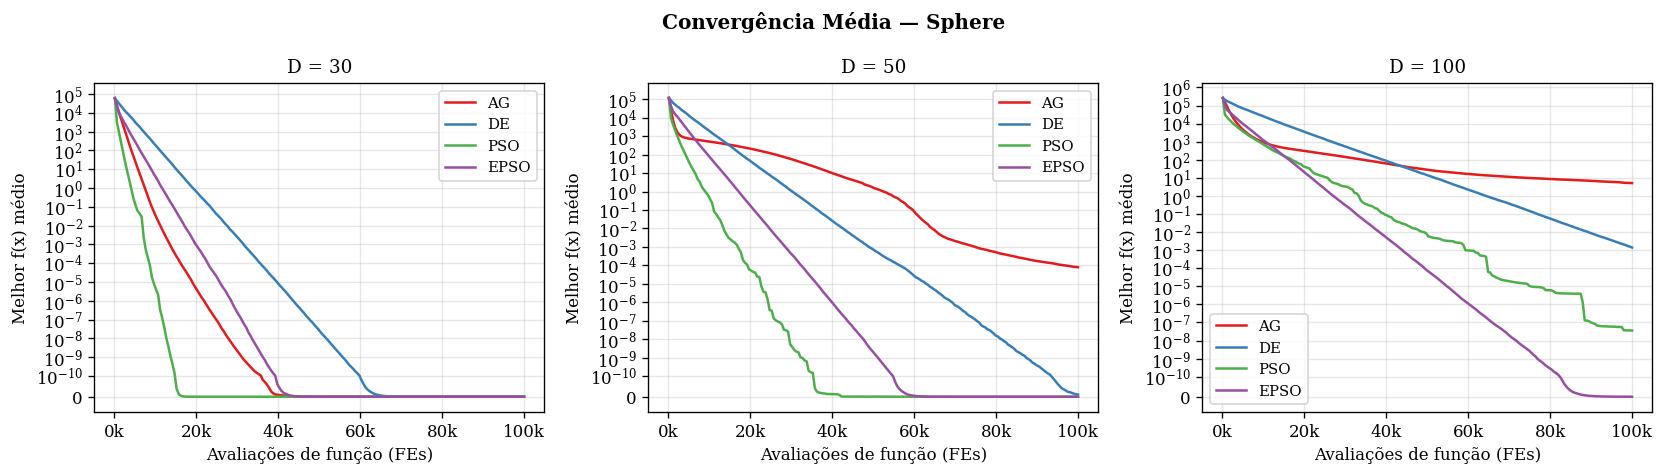

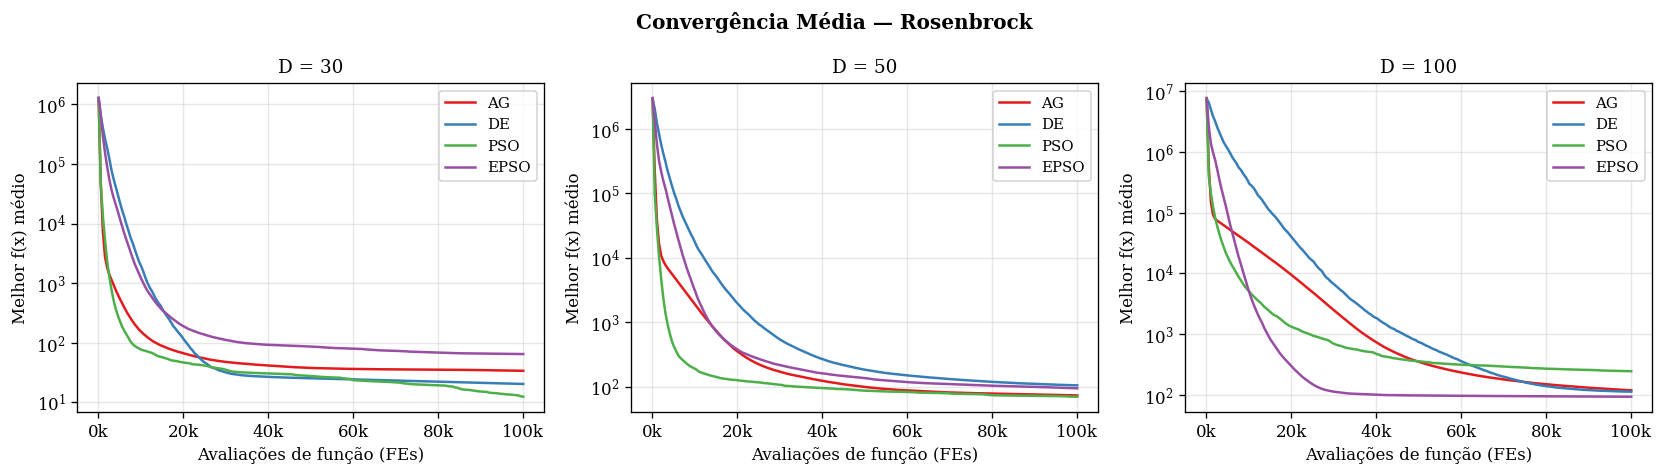

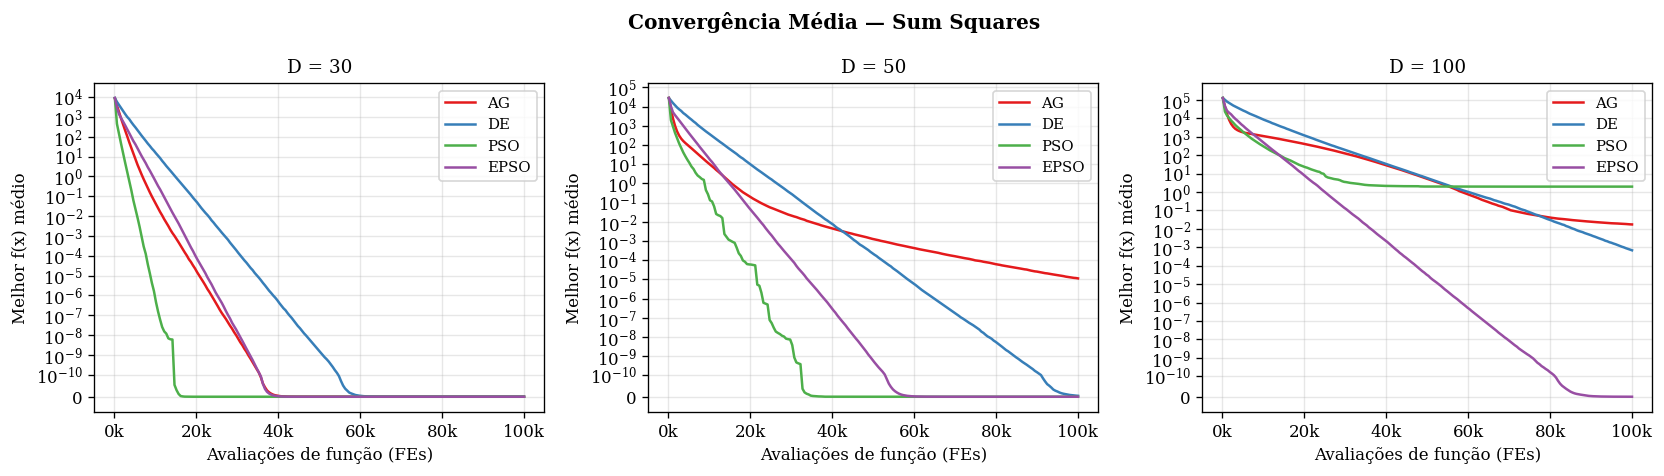

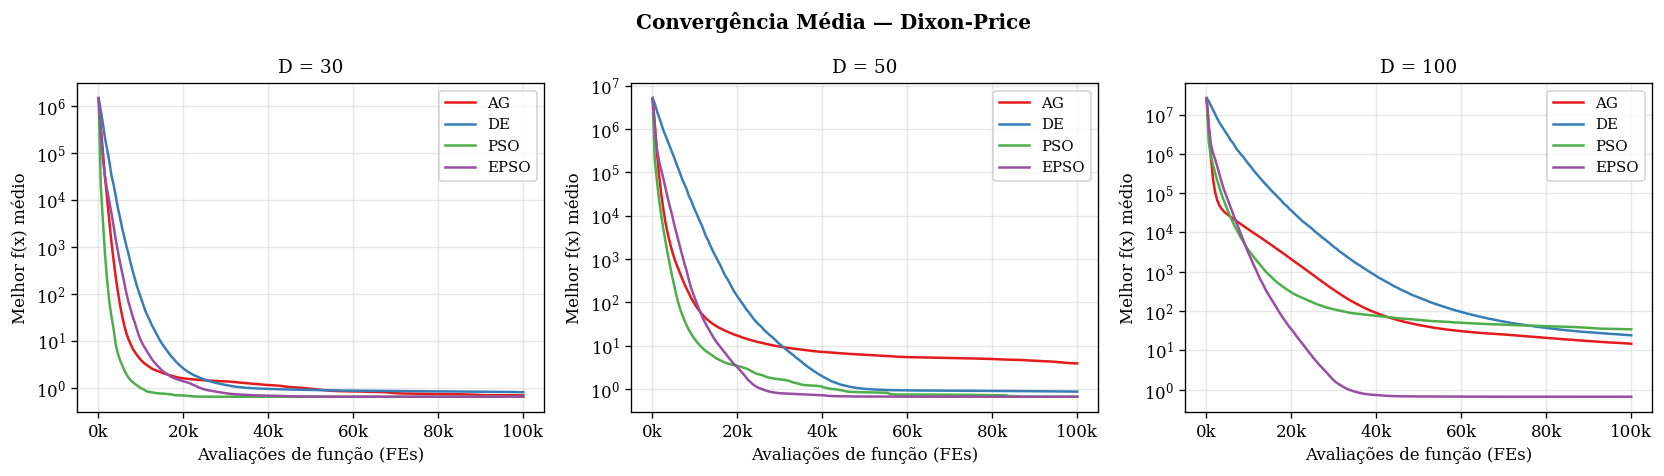

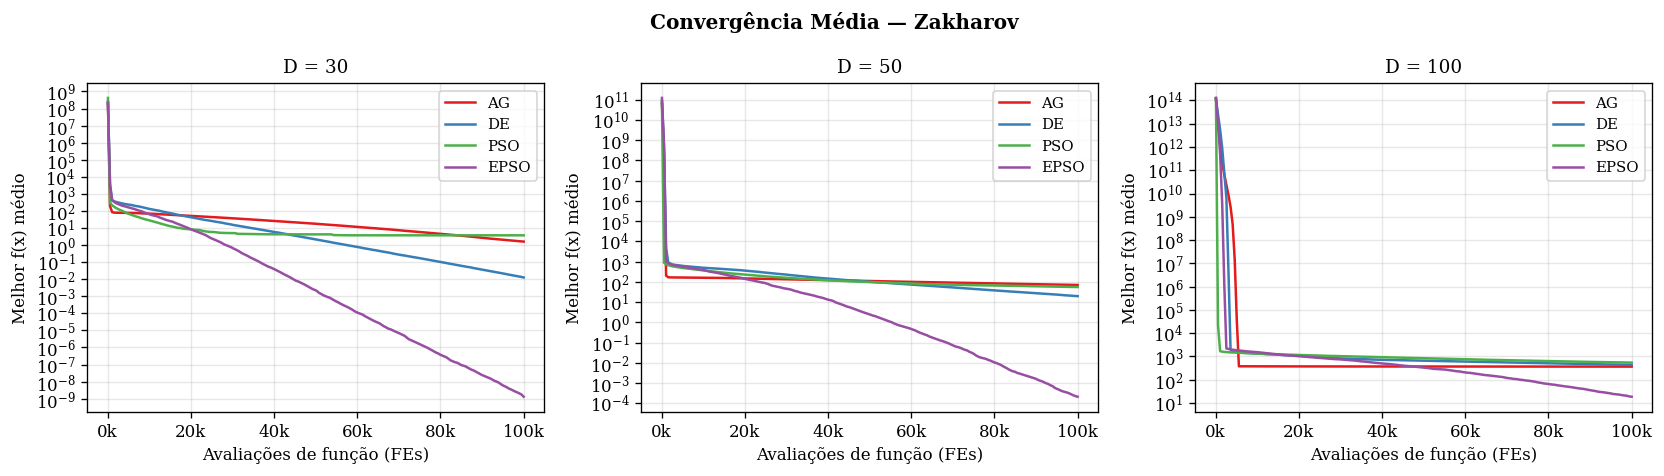


=== MULTIMODAIS ===


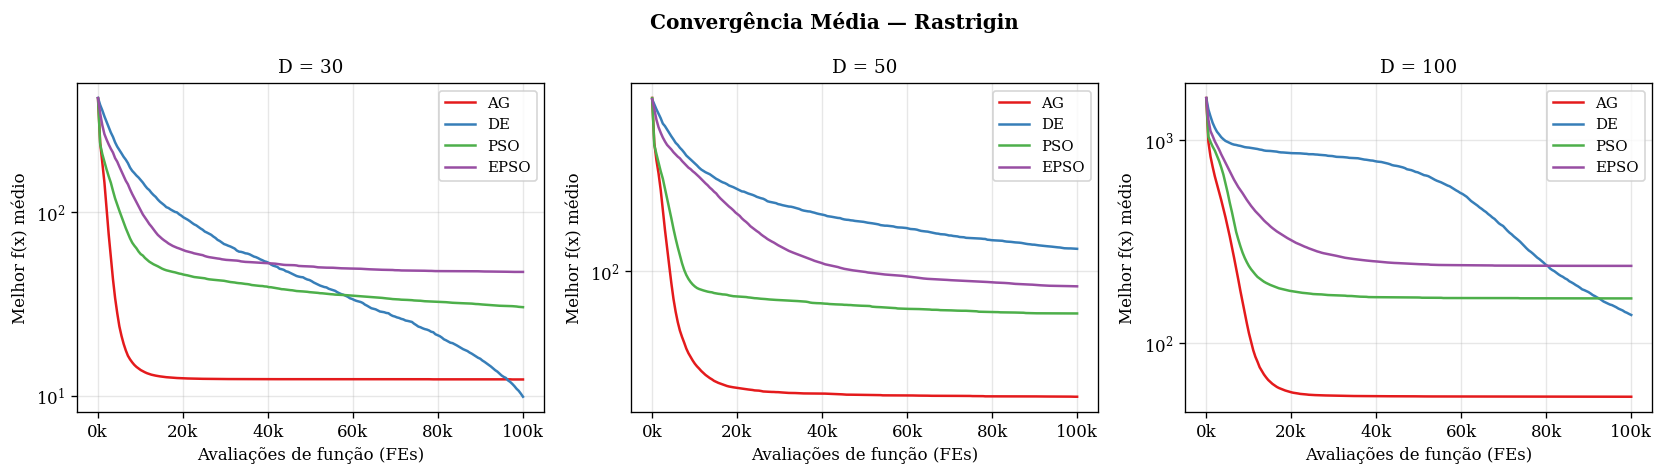

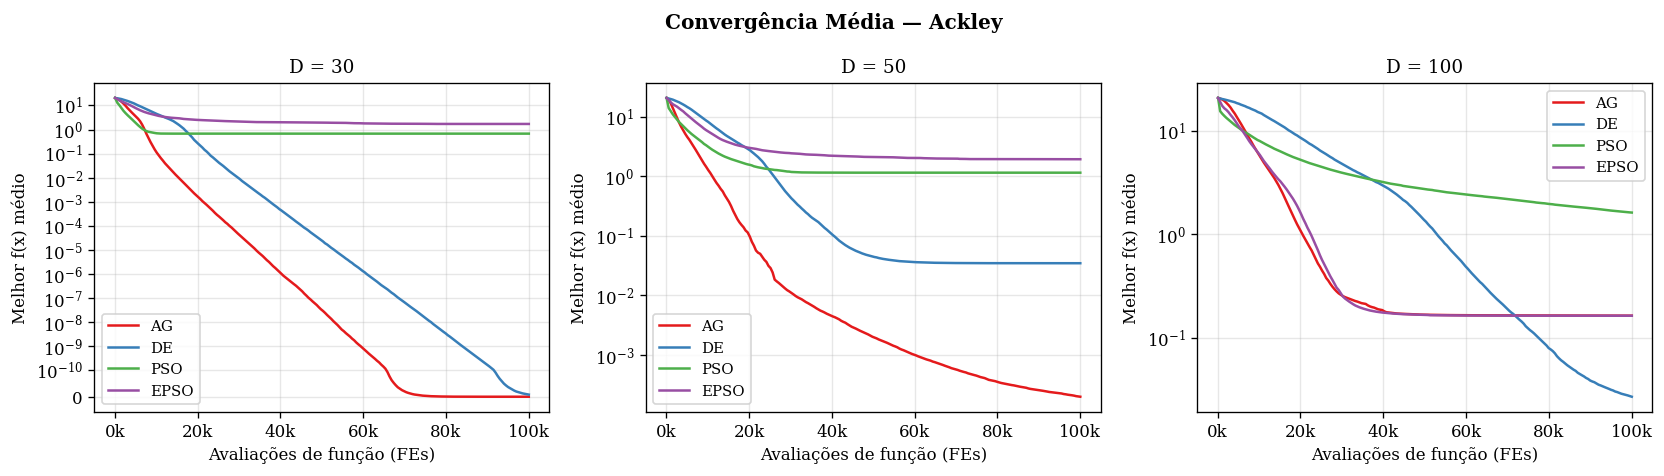

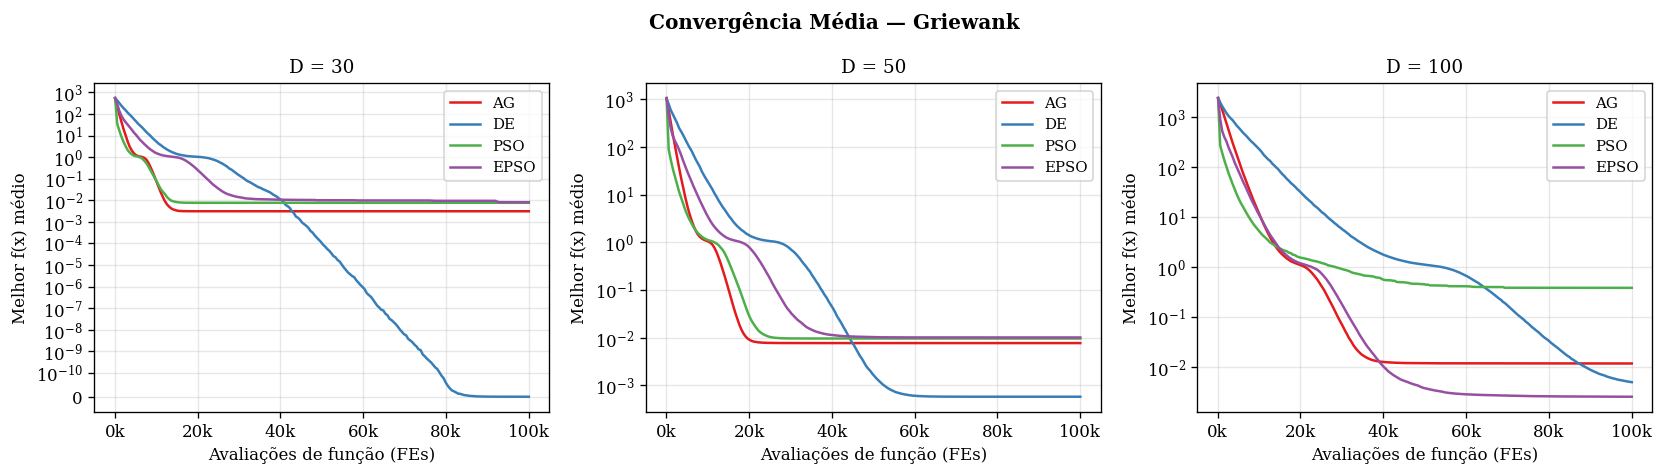

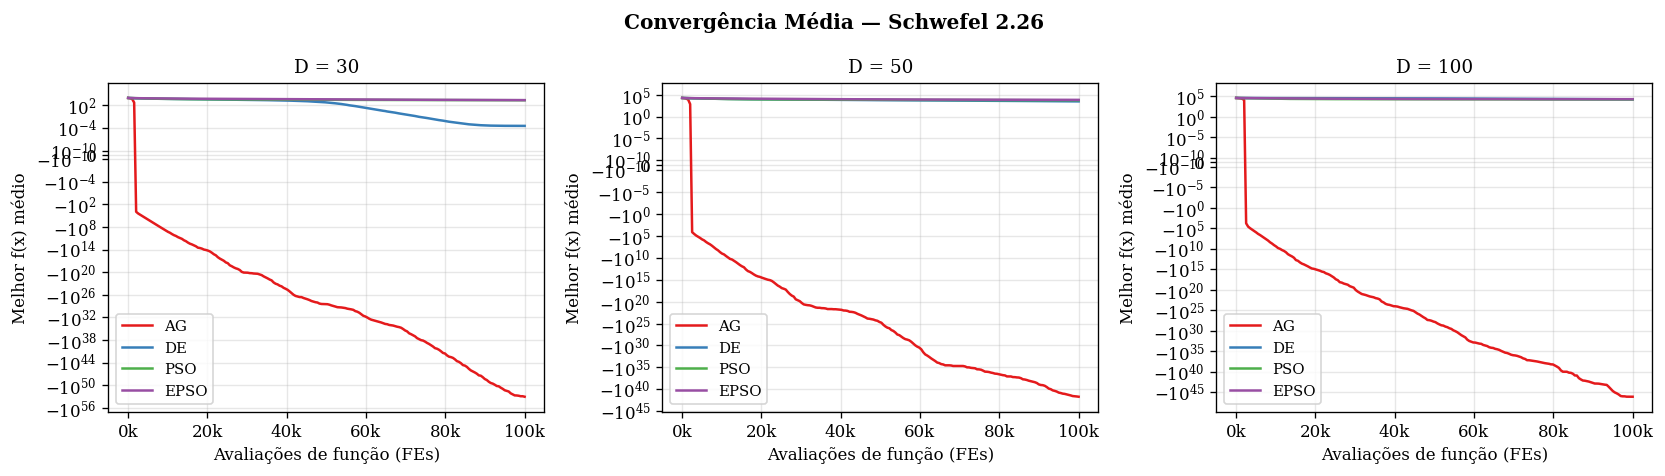

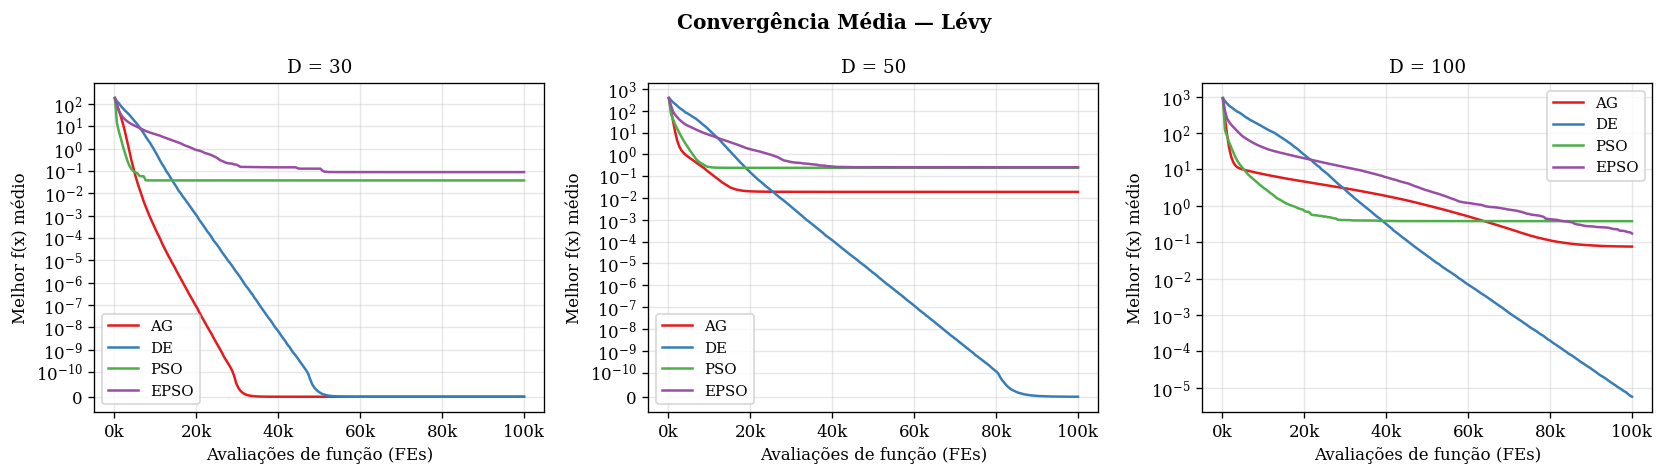

In [23]:
def convergencia_media(his, alg, fn, dim, n_pontos=200):
    """
    Interpola todas as execuções em uma grade comum de FEs
    e retorna média e desvio padrão ponto a ponto.
    """
    sub = his[(his.algoritmo == alg) & (his.funcao == fn) & (his.dim == dim)]
    fes_max = sub['n_fes'].max()
    grid    = np.linspace(sub['n_fes'].min(), fes_max, n_pontos)
    curvas  = []
    for eid, grp in sub.groupby('exec_id'):
        grp = grp.sort_values('n_fes')
        curvas.append(np.interp(grid, grp['n_fes'].values, grp['best_f'].values))
    curvas = np.array(curvas)
    return grid, curvas.mean(axis=0), curvas.std(axis=0)


def plot_convergencia(fn, dims=None, log_y=True, figsize=(14, 4)):
    """Curvas de convergência média para uma função, 1 subplot por dimensão."""
    if dims is None:
        dims = DIMS
    fig, axes = plt.subplots(1, len(dims), figsize=figsize, sharey=False)
    if len(dims) == 1:
        axes = [axes]

    for ax, dim in zip(axes, dims):
        for alg in ALGORITMOS:
            grid, mu, sd = convergencia_media(his, alg, fn, dim)
            ax.plot(grid, mu, label=LABELS[alg],
                    color=COLORS[alg], linewidth=1.5)
        ax.set_title(f'D = {dim}')
        ax.set_xlabel('Avaliações de função (FEs)')
        ax.set_ylabel('Melhor f(x) médio')
        if log_y:
            ax.set_yscale('symlog', linthresh=1e-10)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
        ax.legend()

    fig.suptitle(f'Convergência Média — {NOME_FUNCAO[fn]}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(imagens_dir / f'conv_{fn}.png', bbox_inches='tight')
    plt.show()


# ── Plota todas as funções ────────────────────────────────────────────────────
print('=== UNIMODAIS ===')
for fn in UNIMODAIS:
    plot_convergencia(fn)

print('\n=== MULTIMODAIS ===')
for fn in MULTIMODAIS:
    plot_convergencia(fn)

## 4. Boxplots por Função

=== UNIMODAIS ===


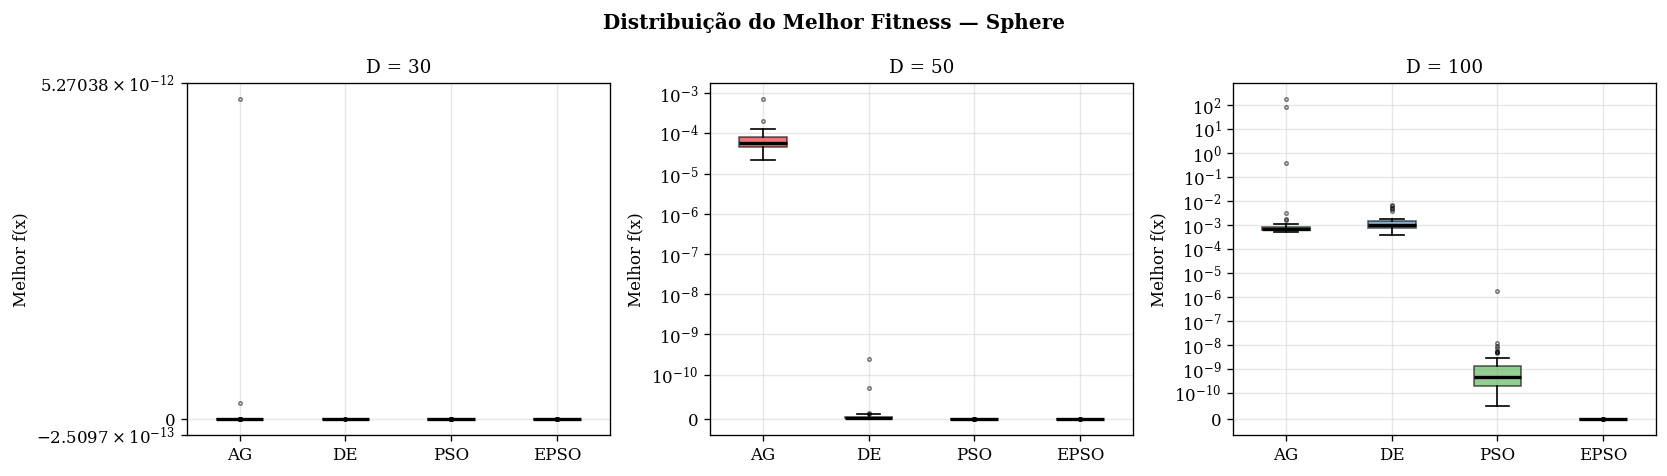

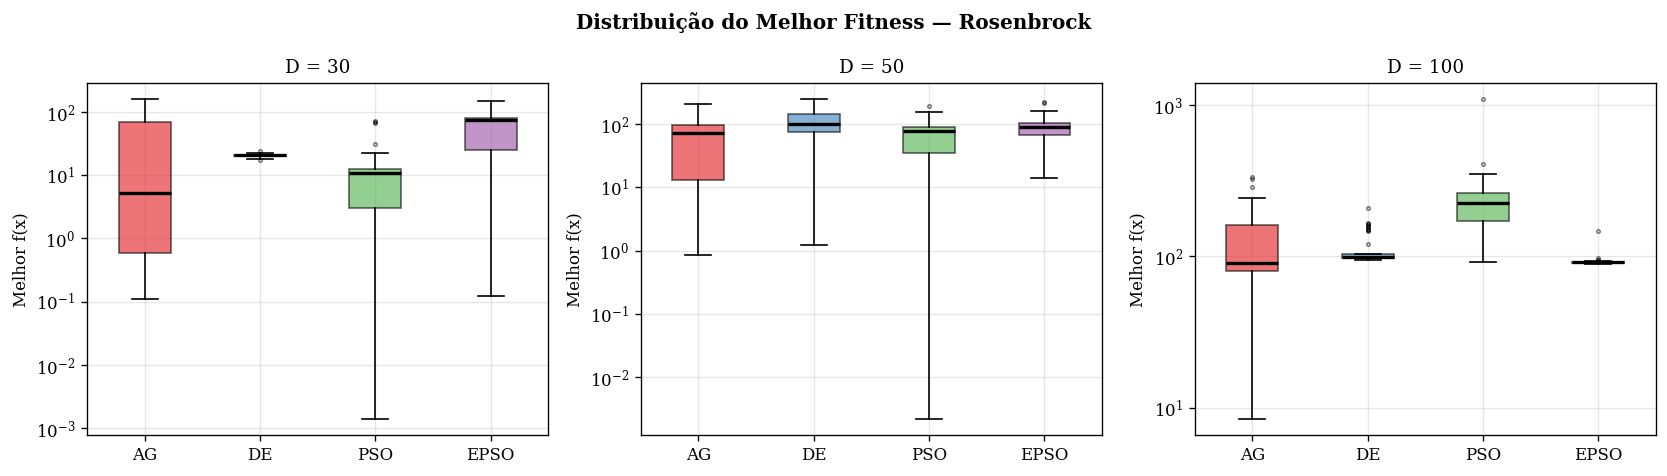

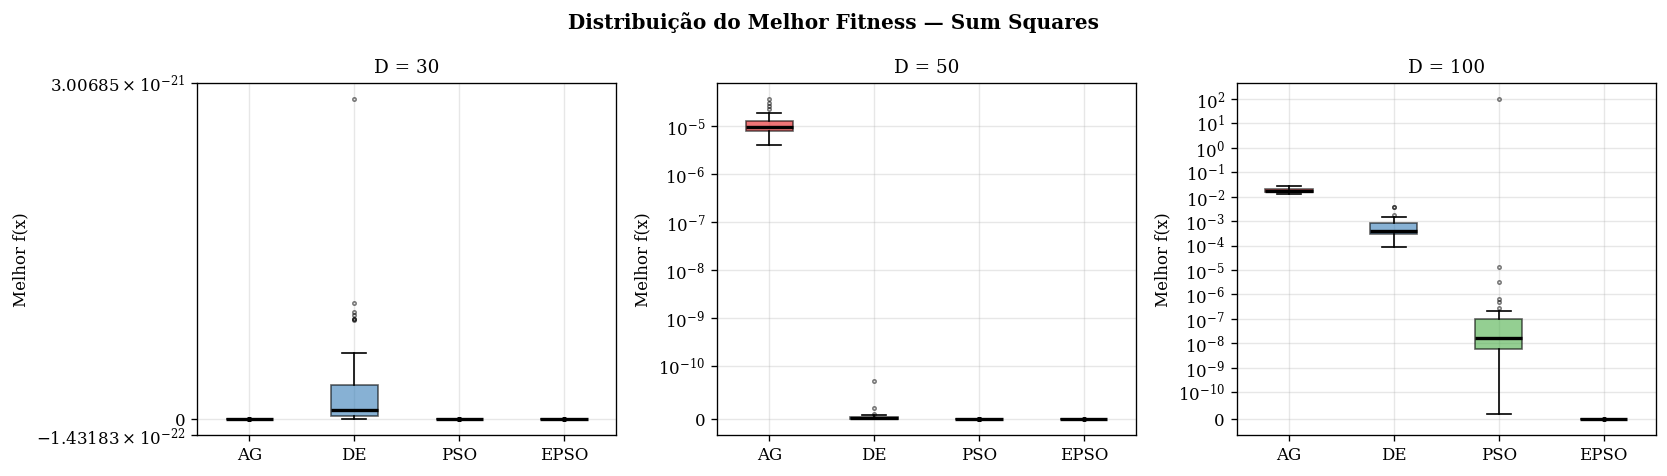

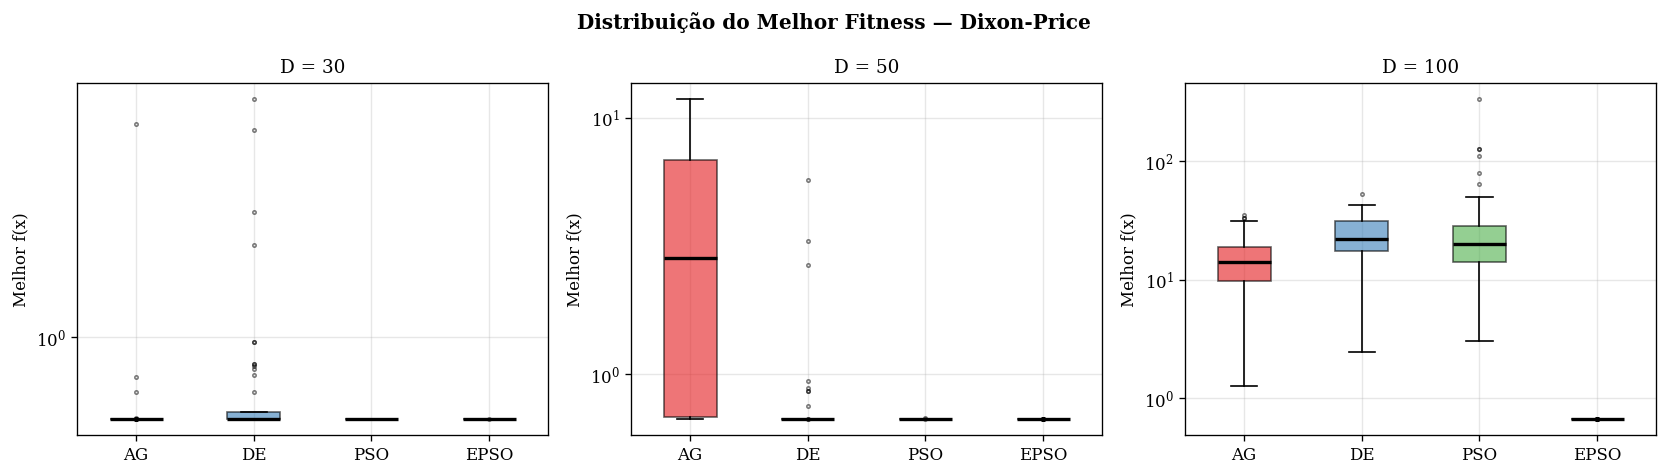

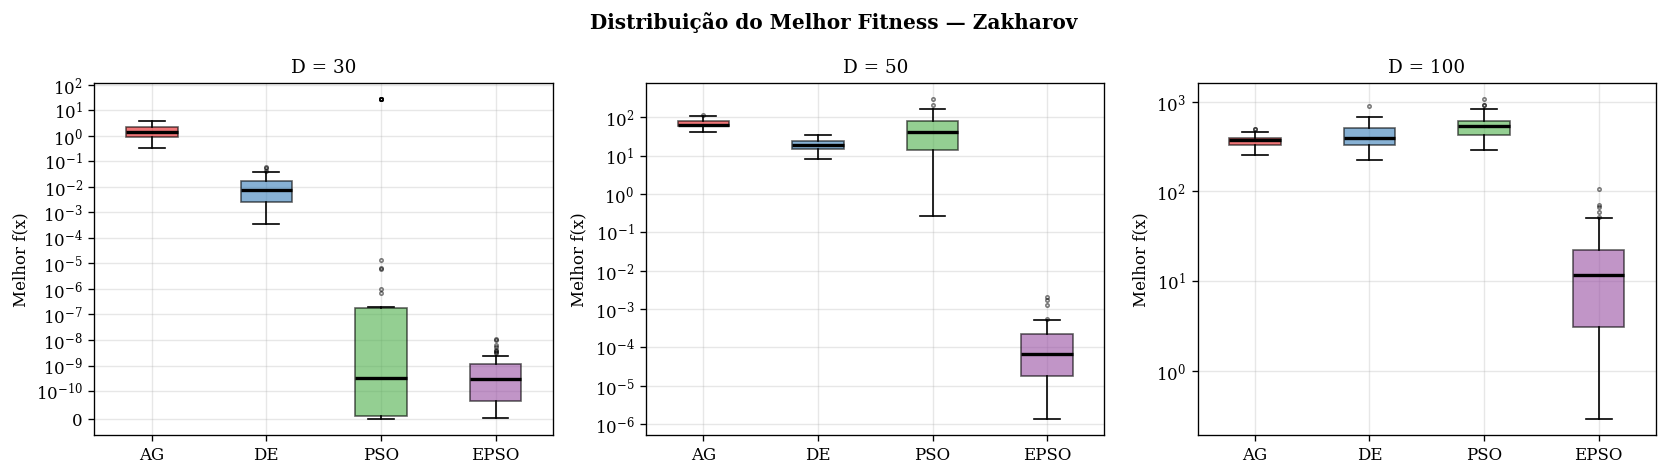


=== MULTIMODAIS ===


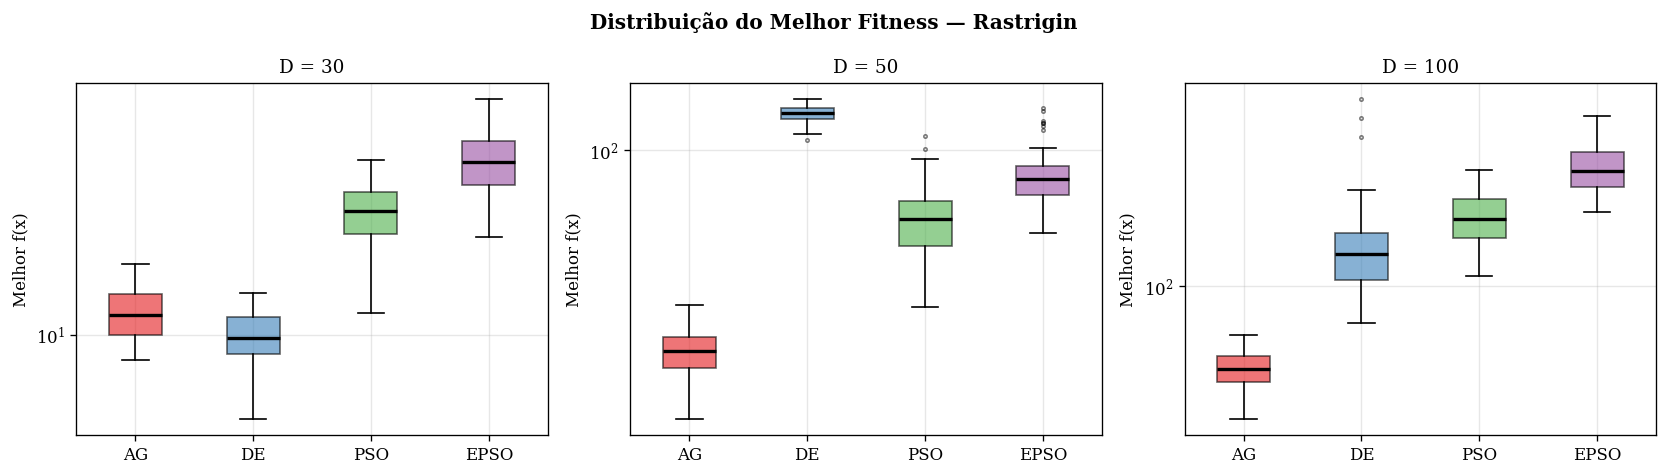

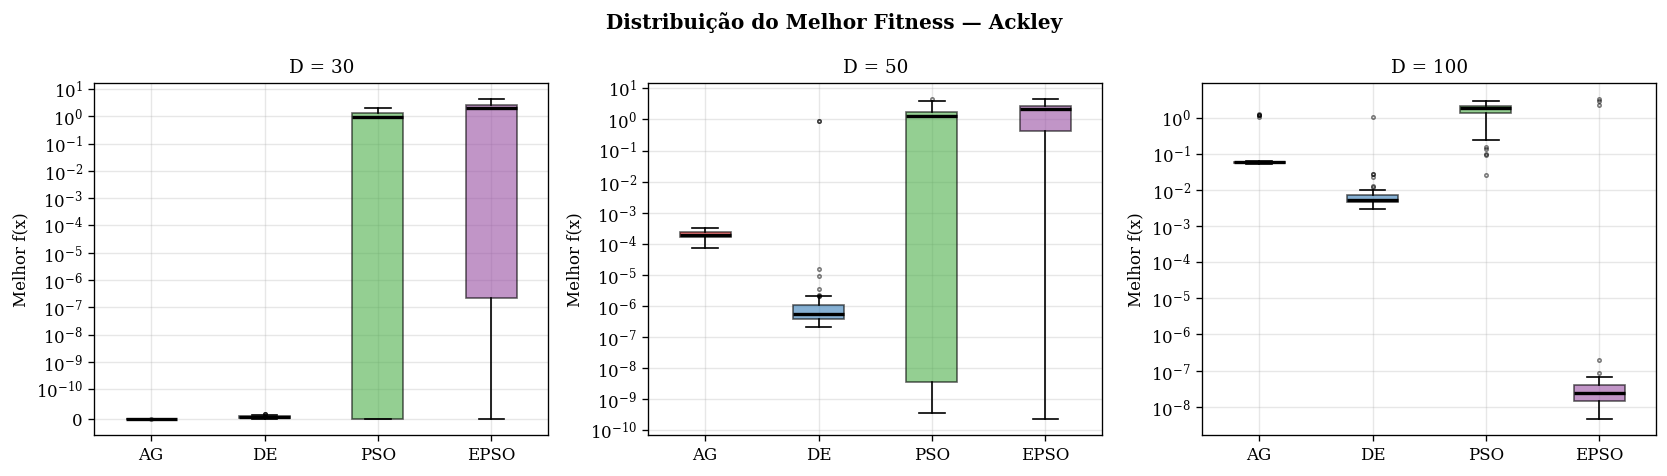

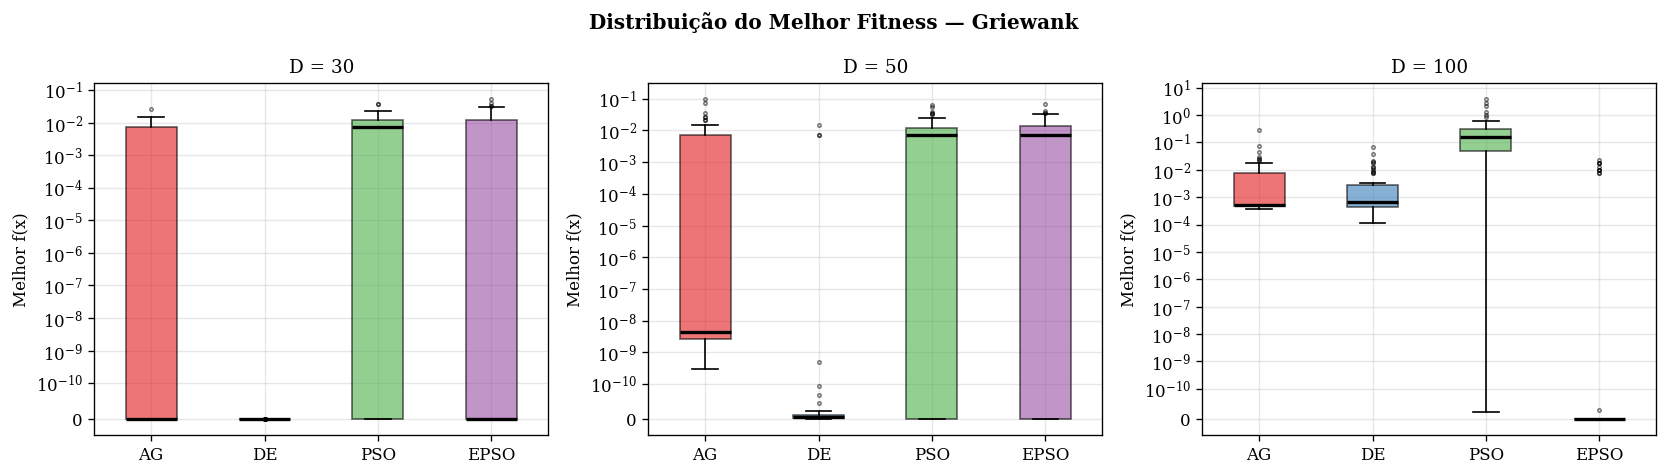

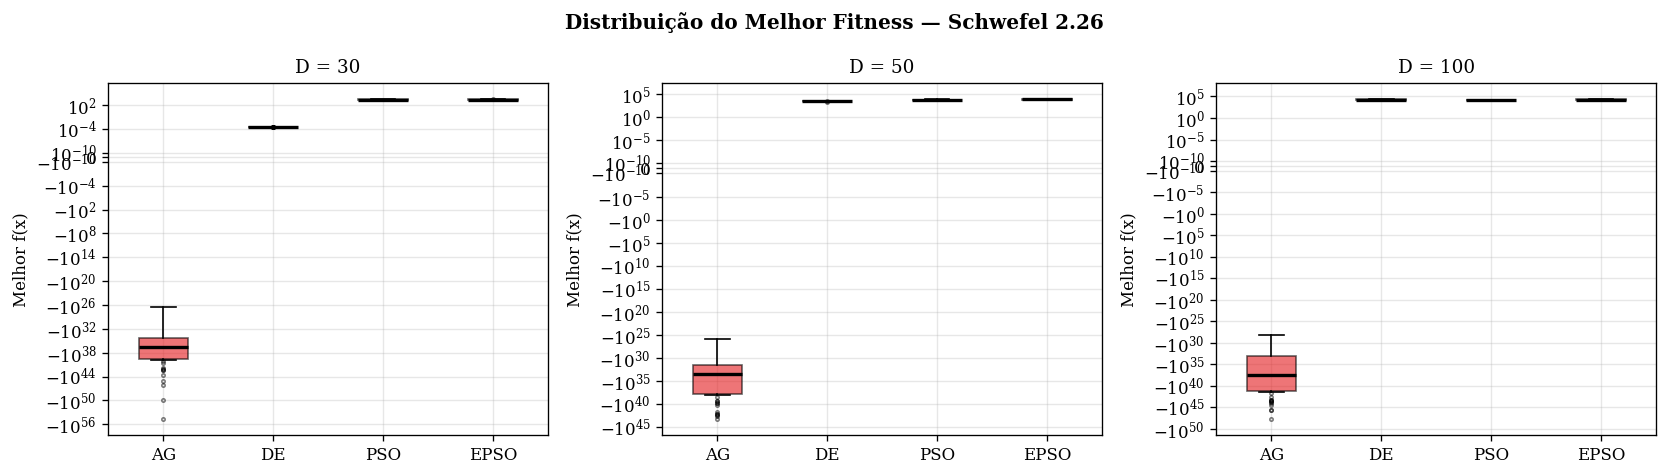

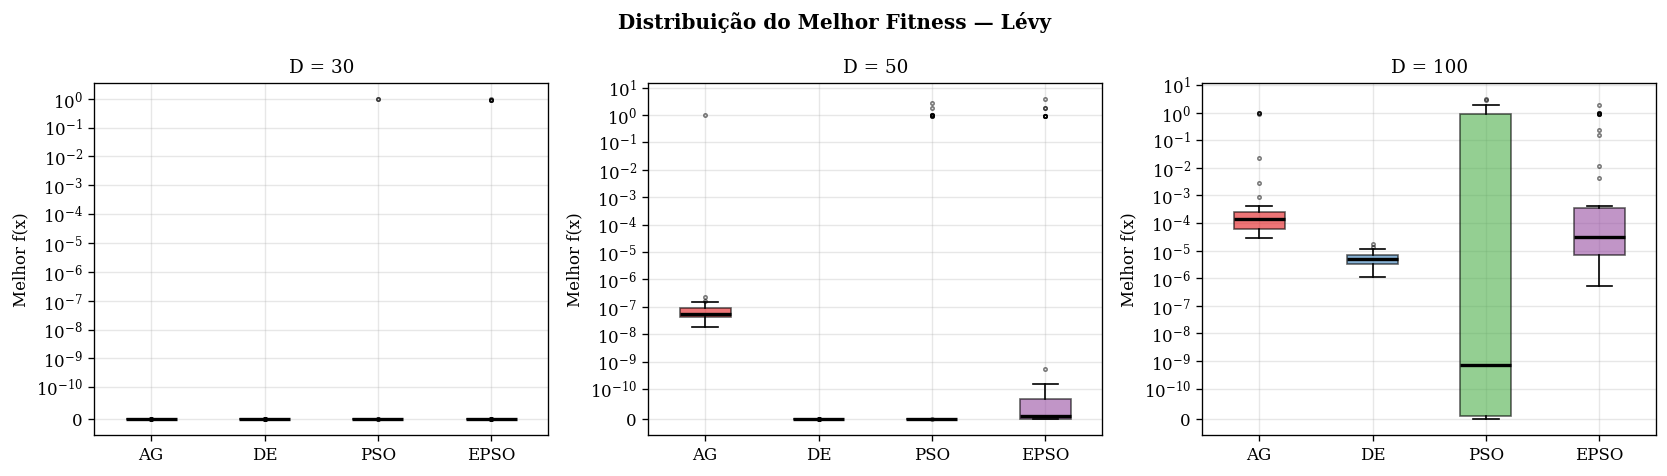

In [24]:
def plot_boxplot(fn, dims=None, log_y=True, figsize=(14, 4)):
    """Boxplot do best_f final para uma função, 1 subplot por dimensão."""
    if dims is None:
        dims = DIMS
    fig, axes = plt.subplots(1, len(dims), figsize=figsize, sharey=False)
    if len(dims) == 1:
        axes = [axes]

    for ax, dim in zip(axes, dims):
        data   = [res[(res.algoritmo == a) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
                  for a in ALGORITMOS]
        labels = [LABELS[a] for a in ALGORITMOS]

        bp = ax.boxplot(data, labels=labels, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        flierprops=dict(marker='.', markersize=4, alpha=0.5))
        for patch, alg in zip(bp['boxes'], ALGORITMOS):
            patch.set_facecolor(COLORS[alg])
            patch.set_alpha(0.6)

        ax.set_title(f'D = {dim}')
        ax.set_ylabel('Melhor f(x)')
        if log_y:
            ax.set_yscale('symlog', linthresh=1e-10)

    fig.suptitle(f'Distribuição do Melhor Fitness — {NOME_FUNCAO[fn]}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(imagens_dir / f'box_{fn}.png', bbox_inches='tight')
    plt.show()


print('=== UNIMODAIS ===')
for fn in UNIMODAIS:
    plot_boxplot(fn)

print('\n=== MULTIMODAIS ===')
for fn in MULTIMODAIS:
    plot_boxplot(fn)

## 5. Análise Estatística 

### 5.1 Teste T Pareado
Seguindo Marcelino et al. (2018): Teste T com α = 5%, hipótese nula de igualdade de médias.  
Para cada par de algoritmos, por função e dimensão: reportar p-valor e vencedor.

$H_0$: As médias são estatisticamente iguais


| Decisão | Significado | 
| :--- | :---: | 
| Rejeita  H₀ (p < 0.05) | As médias são diferentes → dá para apontar um vencedor |
| Não rejeita H₀ (p ≥ 0.05) | Não há evidência de diferença → os algoritmos são estatisticamente equivalentes nessa configuração | 


In [25]:
def teste_t_pairwise(fn, dim, alpha=0.05):
    """
    Teste T pareado para todos os pares de algoritmos.
    Retorna DataFrame com p-valor e vencedor.
    """
    pares = list(combinations(ALGORITMOS, 2))
    rows  = []
    for a1, a2 in pares:
        v1 = res[(res.algoritmo == a1) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
        v2 = res[(res.algoritmo == a2) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
        _, pval = stats.ttest_ind(v1, v2)
        if pval < alpha:
            vencedor = LABELS[a1] if v1.mean() < v2.mean() else LABELS[a2]
        else:
            vencedor = '—'
        rows.append({
            'Par': f'{LABELS[a1]} × {LABELS[a2]}',
            'p-valor': f'{pval:.2e}',
            'Decisão': 'Rejeita H₀' if pval < alpha else 'Não rejeita H₀',
            'Vencedor': vencedor
        })
    return pd.DataFrame(rows)


def tabela_estatistica(fn):
    print(f'\n{'═'*70}')
    print(f'  Teste T — {NOME_FUNCAO[fn]}')
    print(f'{'═'*70}')
    for dim in DIMS:
        print(f'\n  D = {dim}')
        display(teste_t_pairwise(fn, dim).set_index('Par'))


for fn in FUNCOES:
    tabela_estatistica(fn)


══════════════════════════════════════════════════════════════════════
  Teste T — Sphere
══════════════════════════════════════════════════════════════════════

  D = 30


,p-valor,Decisão,Vencedor
Par,,,
AG × DE,2.96e-01,Não rejeita H₀,—
AG × PSO,2.96e-01,Não rejeita H₀,—
AG × EPSO,2.96e-01,Não rejeita H₀,—
DE × PSO,5.83e-09,Rejeita H₀,PSO
DE × EPSO,5.83e-09,Rejeita H₀,EPSO
PSO × EPSO,2.42e-01,Não rejeita H₀,—



  D = 50


,p-valor,Decisão,Vencedor
Par,,,
AG × DE,6.70e-08,Rejeita H₀,DE
AG × PSO,6.70e-08,Rejeita H₀,PSO
AG × EPSO,6.70e-08,Rejeita H₀,EPSO
DE × PSO,3.83e-02,Rejeita H₀,PSO
DE × EPSO,3.83e-02,Rejeita H₀,EPSO
PSO × EPSO,9.06e-04,Rejeita H₀,PSO



  D = 100


...

,p-valor,Decisão,Vencedor
Par,,,
AG × DE,5.50e-04,Rejeita H₀,AG
AG × PSO,1.56e-01,Não rejeita H₀,—
AG × EPSO,2.18e-02,Rejeita H₀,AG
DE × PSO,1.56e-01,Não rejeita H₀,—
DE × EPSO,2.18e-02,Rejeita H₀,DE
PSO × EPSO,2.72e-01,Não rejeita H₀,—



  D = 50


,p-valor,Decisão,Vencedor
Par,,,
AG × DE,3.20e-01,Não rejeita H₀,—
AG × PSO,7.44e-03,Rejeita H₀,AG
AG × EPSO,1.75e-02,Rejeita H₀,AG
DE × PSO,2.93e-03,Rejeita H₀,DE
DE × EPSO,9.08e-03,Rejeita H₀,DE
PSO × EPSO,9.11e-01,Não rejeita H₀,—



  D = 100


,p-valor,Decisão,Vencedor
Par,,,
AG × DE,4.00e-02,Rejeita H₀,DE
AG × PSO,6.54e-03,Rejeita H₀,AG
AG × EPSO,1.51e-01,Não rejeita H₀,—
DE × PSO,3.74e-04,Rejeita H₀,DE
DE × EPSO,2.91e-03,Rejeita H₀,DE
PSO × EPSO,8.31e-02,Não rejeita H₀,—


### 5.2 Kruskal-Wallis 
"Existe ao menos um algoritmo diferente dos demais nessa função/dimensão?"

$H_0$: as distribuições do best_f são iguais entre todos os algoritmos

Rejeita H0 (p < alpha): ao menos um algoritmo difere dos demais → faz sentido rodar Wilcoxon pairwise

Não rejeita $H0$ (p >= alpha): nenhuma diferença detectada → não rodar pairwise (evita comparações sem evidência prévia)

In [26]:
from scipy.stats import kruskal

# Kruskal-Wallis: teste preliminar antes dos pairwise (Wilcoxon)
# H0: as distribuições do best_f são iguais entre todos os algoritmos
# Rejeita H0 (p < alpha): ao menos um algoritmo difere dos demais
#   → faz sentido rodar Wilcoxon pairwise
# Não rejeita H0 (p >= alpha): nenhuma diferença detectada
#   → não rodar pairwise (evita comparações sem evidência prévia)

def kruskal_wallis(fn, dim, alpha=0.05):
    grupos = [
        res[(res.algoritmo == a) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
        for a in ALGORITMOS
    ]
    stat, pval = kruskal(*grupos)

    return {
        'Estatística H': f'{stat:.4f}',
        'p-valor'      : f'{pval:.2e}',
        'Decisão'      : 'Rejeita H₀ → rodar pairwise' if pval < alpha else 'Não rejeita H₀ → pairwise desnecessário',
    }


def tabela_kruskal(funcoes, titulo):
    print(f'\n{"═"*70}')
    print(f'  Kruskal-Wallis — {titulo}  (α = 5%)')
    print(f'{"═"*70}')
    rows = []
    for fn in funcoes:
        for dim in DIMS:
            r = kruskal_wallis(fn, dim)
            rows.append({'Função': NOME_FUNCAO[fn], 'D': dim, **r})
    display(pd.DataFrame(rows).set_index(['Função', 'D']))


tabela_kruskal(UNIMODAIS,   'Funções Unimodais')
tabela_kruskal(MULTIMODAIS, 'Funções Multimodais')


══════════════════════════════════════════════════════════════════════
  Kruskal-Wallis — Funções Unimodais  (α = 5%)
══════════════════════════════════════════════════════════════════════


Estatística H   p-valor                      Decisão
Função      D                                                       
Sphere      30       173.8028  1.92e-37  Rejeita H₀ → rodar pairwise
            50       190.3171  5.21e-41  Rejeita H₀ → rodar pairwise
            100      173.7447  1.98e-37  Rejeita H₀ → rodar pairwise
Rosenbrock  30        69.8226  4.66e-15  Rejeita H₀ → rodar pairwise
            50        19.5597  2.09e-04  Rejeita H₀ → rodar pairwise
            100      107.8560  3.17e-23  Rejeita H₀ → rodar pairwise
Sum Squares 30       190.2294  5.45e-41  Rejeita H₀ → rodar pairwise
            50       190.3171  5.21e-41  Rejeita H₀ → rodar pairwise
            100      185.9268  4.63e-40  Rejeita H₀ → rodar pairwise
Dixon-Price 30        34.5388  1.52e-07  Rejeita H₀ → rodar pairwise
            50       150.0689  2.55e-32  Rejeita H₀ → rodar pairwise
            100      126.1400  3.67e-27  Rejeita H₀ → rodar pairwise
Zakharov    30       134.0922  7.10e-29  Rejeita H₀ → rodar pairwise
            50       151.1653  1.48e-32  Rejeita H₀ → rodar pairwise
            100      136.4627  2.19e-29  Rejeita H₀ → rodar pairwise


══════════════════════════════════════════════════════════════════════
  Kruskal-Wallis — Funções Multimodais  (α = 5%)
══════════════════════════════════════════════════════════════════════


Estatística H   p-valor                      Decisão
Função        D                                                       
Rastrigin     30       163.4815  3.25e-35  Rejeita H₀ → rodar pairwise
              50       177.0582  3.81e-38  Rejeita H₀ → rodar pairwise
              100      163.1444  3.84e-35  Rejeita H₀ → rodar pairwise
Ackley        30       142.6325  1.02e-30  Rejeita H₀ → rodar pairwise
              50        55.7924  4.65e-12  Rejeita H₀ → rodar pairwise
              100      161.1841  1.02e-34  Rejeita H₀ → rodar pairwise
Griewank      30        22.5248  5.07e-05  Rejeita H₀ → rodar pairwise
              50        23.6162  3.00e-05  Rejeita H₀ → rodar pairwise
              100       97.0806  6.59e-21  Rejeita H₀ → rodar pairwise
Schwefel 2.26 30       171.6439  5.62e-37  Rejeita H₀ → rodar pairwise
              50       181.9715  3.31e-39  Rejeita H₀ → rodar pairwise
              100      131.1548  3.05e-28  Rejeita H₀ → rodar pairwise
Lévy          30       149.0914  4.14e-32  Rejeita H₀ → rodar pairwise
              50       106.7378  5.52e-23  Rejeita H₀ → rodar pairwise
              100       66.7724  2.09e-14  Rejeita H₀ → rodar pairwise

### 5.3 Teste Wilcoxon


In [27]:
from scipy.stats import mannwhitneyu
from itertools import combinations

# H0: as distribuições do best_f dos dois algoritmos são iguais
# Rejeita H0 (p < alpha): há diferença significativa → aponta vencedor (menor mediana)
# Não rejeita H0 (p >= alpha): algoritmos são estatisticamente equivalentes

def wilcoxon_pairwise(fn, dim, alpha=0.05):
    pares = list(combinations(ALGORITMOS, 2))
    rows  = []
    for a1, a2 in pares:
        v1 = res[(res.algoritmo == a1) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
        v2 = res[(res.algoritmo == a2) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values

        # alternative='two-sided': detecta diferença em qualquer direção
        _, pval = mannwhitneyu(v1, v2, alternative='two-sided')

        if pval < alpha:
            vencedor = LABELS[a1] if np.median(v1) < np.median(v2) else LABELS[a2]
            decisao  = 'Rejeita H₀'
        else:
            vencedor = '—'
            decisao  = 'Não rejeita H₀'

        rows.append({
            'Par'     : f'{LABELS[a1]} × {LABELS[a2]}',
            'p-valor' : f'{pval:.2e}',
            'Decisão' : decisao,
            'Vencedor': vencedor,
        })
    return pd.DataFrame(rows)


def tabela_wilcoxon(fn):
    print(f'\n{"═"*70}')
    print(f'  Wilcoxon Rank-Sum — {NOME_FUNCAO[fn]}  (α = 5%)')
    print(f'{"═"*70}')
    for dim in DIMS:
        print(f'\n  D = {dim}')
        display(wilcoxon_pairwise(fn, dim).set_index('Par'))


for fn in FUNCOES:
    tabela_wilcoxon(fn)


══════════════════════════════════════════════════════════════════════
  Wilcoxon Rank-Sum — Sphere  (α = 5%)
══════════════════════════════════════════════════════════════════════

  D = 30


,p-valor,Decisão,Vencedor
Par,,,
AG × DE,3.02e-10,Rejeita H₀,AG
AG × PSO,3.30e-18,Rejeita H₀,PSO
AG × EPSO,1.58e-12,Rejeita H₀,EPSO
DE × PSO,3.30e-18,Rejeita H₀,PSO
DE × EPSO,3.30e-18,Rejeita H₀,EPSO
PSO × EPSO,3.30e-18,Rejeita H₀,PSO



  D = 50


,p-valor,Decisão,Vencedor
Par,,,
AG × DE,3.30e-18,Rejeita H₀,DE
AG × PSO,3.30e-18,Rejeita H₀,PSO
AG × EPSO,3.30e-18,Rejeita H₀,EPSO
DE × PSO,3.30e-18,Rejeita H₀,PSO
DE × EPSO,3.30e-18,Rejeita H₀,EPSO
PSO × EPSO,3.30e-18,Rejeita H₀,PSO



  D = 100


...

,p-valor,Decisão,Vencedor
Par,,,
AG × DE,2.80e-18,Rejeita H₀,AG
AG × PSO,3.17e-08,Rejeita H₀,PSO
AG × EPSO,4.22e-18,Rejeita H₀,AG
DE × PSO,4.00e-17,Rejeita H₀,PSO
DE × EPSO,3.66e-01,Não rejeita H₀,—
PSO × EPSO,3.76e-17,Rejeita H₀,PSO



  D = 50


,p-valor,Decisão,Vencedor
Par,,,
AG × DE,3.30e-18,Rejeita H₀,DE
AG × PSO,6.53e-08,Rejeita H₀,PSO
AG × EPSO,1.44e-08,Rejeita H₀,EPSO
DE × PSO,8.82e-08,Rejeita H₀,PSO
DE × EPSO,5.27e-16,Rejeita H₀,DE
PSO × EPSO,2.01e-08,Rejeita H₀,PSO



  D = 100


,p-valor,Decisão,Vencedor
Par,,,
AG × DE,3.30e-18,Rejeita H₀,DE
AG × PSO,3.43e-05,Rejeita H₀,PSO
AG × EPSO,2.33e-03,Rejeita H₀,EPSO
DE × PSO,8.78e-05,Rejeita H₀,PSO
DE × EPSO,1.65e-06,Rejeita H₀,DE
PSO × EPSO,2.34e-05,Rejeita H₀,PSO


### 5.4 Teste de Friedman

In [28]:
from scipy.stats import friedmanchisquare

# Friedman: compara múltiplos algoritmos em múltiplas funções simultaneamente
# H0: os algoritmos têm desempenho equivalente considerando todas as funções
# Rejeita H0 (p < alpha): existe ao menos um algoritmo consistentemente diferente
# → faz sentido rodar Nemenyi post hoc
#
# Estrutura do bloco: cada função×dimensão é um "bloco",
# cada algoritmo é um "tratamento", o valor é o rank do fitness médio.

def friedman_test(dim, alpha=0.05):
    # Para cada função, coleta o vetor de fitness médio dos 4 algoritmos
    # Friedman recebe k vetores (um por algoritmo), cada um com n valores (um por função)
    grupos = {
        alg: [
            res[(res.algoritmo == alg) & (res.funcao == fn) & (res.dim == dim)]['best_f'].median()
            for fn in FUNCOES
        ]
        for alg in ALGORITMOS
    }

    stat, pval = friedmanchisquare(*grupos.values())

    print(f'\n{"═"*60}')
    print(f'  Friedman — D = {dim}  (α = 5%)')
    print(f'{"═"*60}')
    print(f'  Estatística χ²: {stat:.4f}')
    print(f'  p-valor:        {pval:.2e}')
    if pval < alpha:
        print(f'  Decisão:        Rejeita H₀ → rodar Nemenyi post hoc')
    else:
        print(f'  Decisão:        Não rejeita H₀ → algoritmos equivalentes')
    return pval < alpha


friedman_rejeitou = {dim: friedman_test(dim) for dim in DIMS}


════════════════════════════════════════════════════════════
  Friedman — D = 30  (α = 5%)
════════════════════════════════════════════════════════════
  Estatística χ²: 3.1348
  p-valor:        3.71e-01
  Decisão:        Não rejeita H₀ → algoritmos equivalentes

════════════════════════════════════════════════════════════
  Friedman — D = 50  (α = 5%)
════════════════════════════════════════════════════════════
  Estatística χ²: 2.7600
  p-valor:        4.30e-01
  Decisão:        Não rejeita H₀ → algoritmos equivalentes

════════════════════════════════════════════════════════════
  Friedman — D = 100  (α = 5%)
════════════════════════════════════════════════════════════
  Estatística χ²: 4.4400
  p-valor:        2.18e-01
  Decisão:        Não rejeita H₀ → algoritmos equivalentes


In [29]:
import scikit_posthocs as sp
import matplotlib.patches as mpatches

# Nemenyi post hoc — roda apenas quando Friedman rejeita H0
# Compara todos os pares de algoritmos usando diferença crítica (CD)
# baseada nos ranks médios globais entre todas as funções.
#
# Duas saídas:
#   1. Matriz de p-valores (tabela)
#   2. Critical Difference Diagram (figura clássica em benchmarking)

def nemenyi_posthoc(dim, alpha=0.05):
    if not friedman_rejeitou.get(dim, False):
        print(f'D={dim}: Friedman não rejeitou H₀ — Nemenyi desnecessário.')
        return

    # Monta matriz (n_funcoes × n_algoritmos) com medianas
    data = np.array([
        [res[(res.algoritmo == alg) & (res.funcao == fn) & (res.dim == dim)]['best_f'].median()
         for alg in ALGORITMOS]
        for fn in FUNCOES
    ])
    df_data = pd.DataFrame(data, columns=[LABELS[a] for a in ALGORITMOS])

    # p-valores pairwise
    pmat = sp.posthoc_nemenyi_friedman(df_data)

    print(f'\n{"═"*60}')
    print(f'  Nemenyi Post Hoc — D = {dim}  (p-valores)')
    print(f'{"═"*60}')
    display(pmat.round(4))

    # ── Critical Difference Diagram ───────────────────────────────────────────
    # Rank médio de cada algoritmo (menor rank = melhor)
    ranks = df_data.rank(axis=1, ascending=True).mean()
    ranks_sorted = ranks.sort_values()

    # Diferença crítica (Nemenyi, α=0.05, k=4 algoritmos, N=10 funções)
    # CD = q_alpha * sqrt(k(k+1) / 6N)
    k = len(ALGORITMOS)
    N = len(FUNCOES)
    q_alpha = 2.569  # valor crítico tabelado para α=0.05, k=4
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.set_xlim(ranks_sorted.iloc[-1] + CD + 0.2, ranks_sorted.iloc[0] - 0.2)
    ax.set_ylim(-1, 1.5)
    ax.set_xlabel('Rank médio (menor = melhor)')
    ax.set_yticks([])
    ax.spines[['left','right','top']].set_visible(False)
    ax.axhline(0, color='black', linewidth=0.8)

    y_pos = 0.6
    for name, rank in ranks_sorted.items():
        alg_key = [k for k, v in LABELS.items() if v == name][0]
        ax.plot(rank, 0, 'o', color=COLORS[alg_key], markersize=8, zorder=3)
        ax.text(rank, y_pos, name, ha='center', va='bottom',
                fontsize=9, color=COLORS[alg_key], fontweight='bold')

    # Grupos sem diferença significativa — linha conectando algoritmos com p >= alpha
    pares = list(combinations(list(ranks_sorted.index), 2))
    y_line = -0.4
    for a1, a2 in pares:
        if pmat.loc[a1, a2] >= alpha:
            r1, r2 = ranks_sorted[a1], ranks_sorted[a2]
            ax.plot([r1, r2], [y_line, y_line], color='black', linewidth=2.5)
            y_line -= 0.15

    # Barra de CD
    best_rank = ranks_sorted.iloc[0]
    ax.annotate('', xy=(best_rank - CD, 1.2), xytext=(best_rank, 1.2),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
    ax.text(best_rank - CD / 2, 1.35, f'CD={CD:.2f}', ha='center',
            fontsize=8, color='gray')

    ax.set_title(f'Critical Difference Diagram — D={dim}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(imagens_dir / f'cd_diagram_D{dim}.png', bbox_inches='tight')
    plt.show()


for dim in DIMS:
    nemenyi_posthoc(dim)

D=30: Friedman não rejeitou H₀ — Nemenyi desnecessário.
D=50: Friedman não rejeitou H₀ — Nemenyi desnecessário.
D=100: Friedman não rejeitou H₀ — Nemenyi desnecessário.


## 6. Análise de Escalabilidade

Como cada algoritmo degrada com o aumento de D?  
Métrica: razão entre o fitness médio em D=100 e D=30 (quanto maior, pior a escalabilidade).

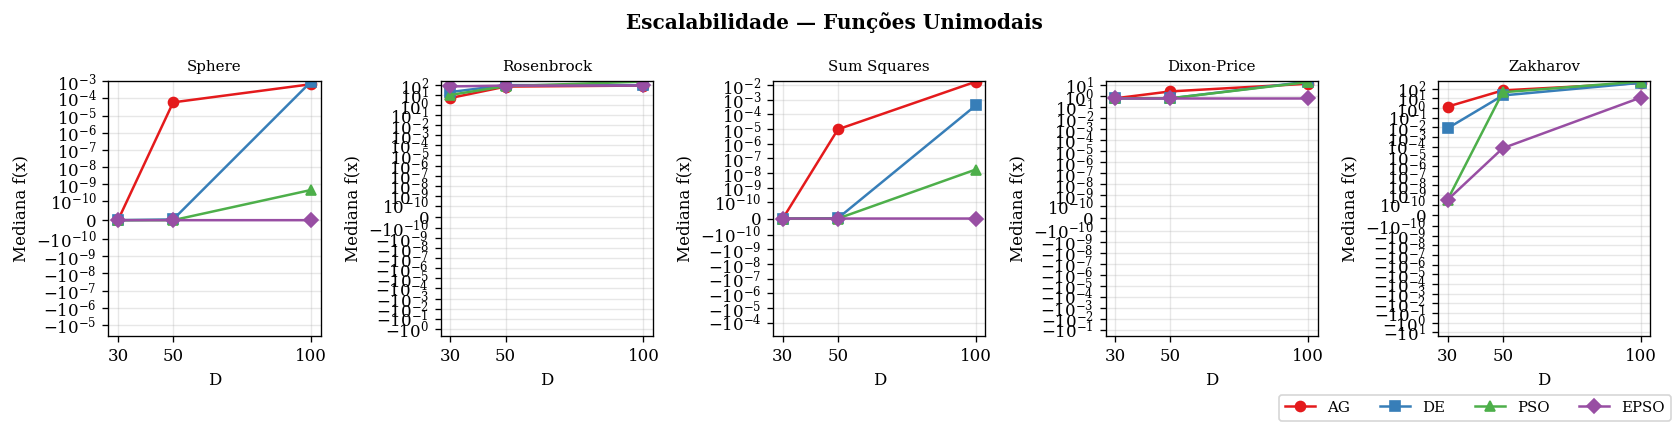

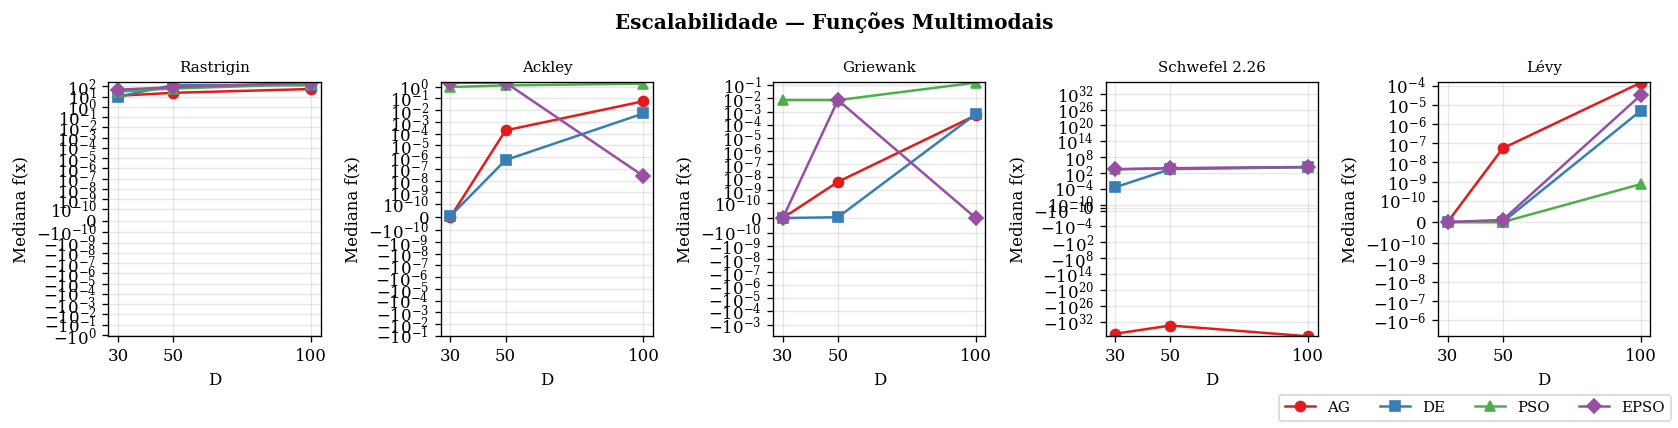

In [30]:
# Escalabilidade — evolução do fitness mediano com o aumento de D
# Para cada algoritmo × função, plota mediana em D=30, 50, 100
# Escala symlog no eixo y para lidar com ordens de magnitude diferentes

def plot_escalabilidade(funcoes, titulo, fname):
    ncols = 5
    nrows = len(funcoes) // ncols + (1 if len(funcoes) % ncols else 0)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
    axes = axes.flatten()

    for idx, fn in enumerate(funcoes):
        ax = axes[idx]
        for alg in ALGORITMOS:
            medianas = [
                res[(res.algoritmo == alg) & (res.funcao == fn) & (res.dim == d)]['best_f'].median()
                for d in DIMS
            ]
            ax.plot(DIMS, medianas,
                    label=LABELS[alg], color=COLORS[alg],
                    marker=MARKERS[alg], linewidth=1.5, markersize=6)

        ax.set_title(NOME_FUNCAO[fn], fontsize=9)
        ax.set_xticks(DIMS)
        ax.set_xlabel('D')
        ax.set_ylabel('Mediana f(x)')
        ax.set_yscale('symlog', linthresh=1e-10)

    for idx in range(len(funcoes), len(axes)):
        fig.delaxes(axes[idx])

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', ncol=4, fontsize=9)
    fig.suptitle(titulo, fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(imagens_dir / fname, bbox_inches='tight')
    plt.show()


plot_escalabilidade(UNIMODAIS,   'Escalabilidade — Funções Unimodais',   'escal_unimodais.png')
plot_escalabilidade(MULTIMODAIS, 'Escalabilidade — Funções Multimodais', 'escal_multimodais.png')

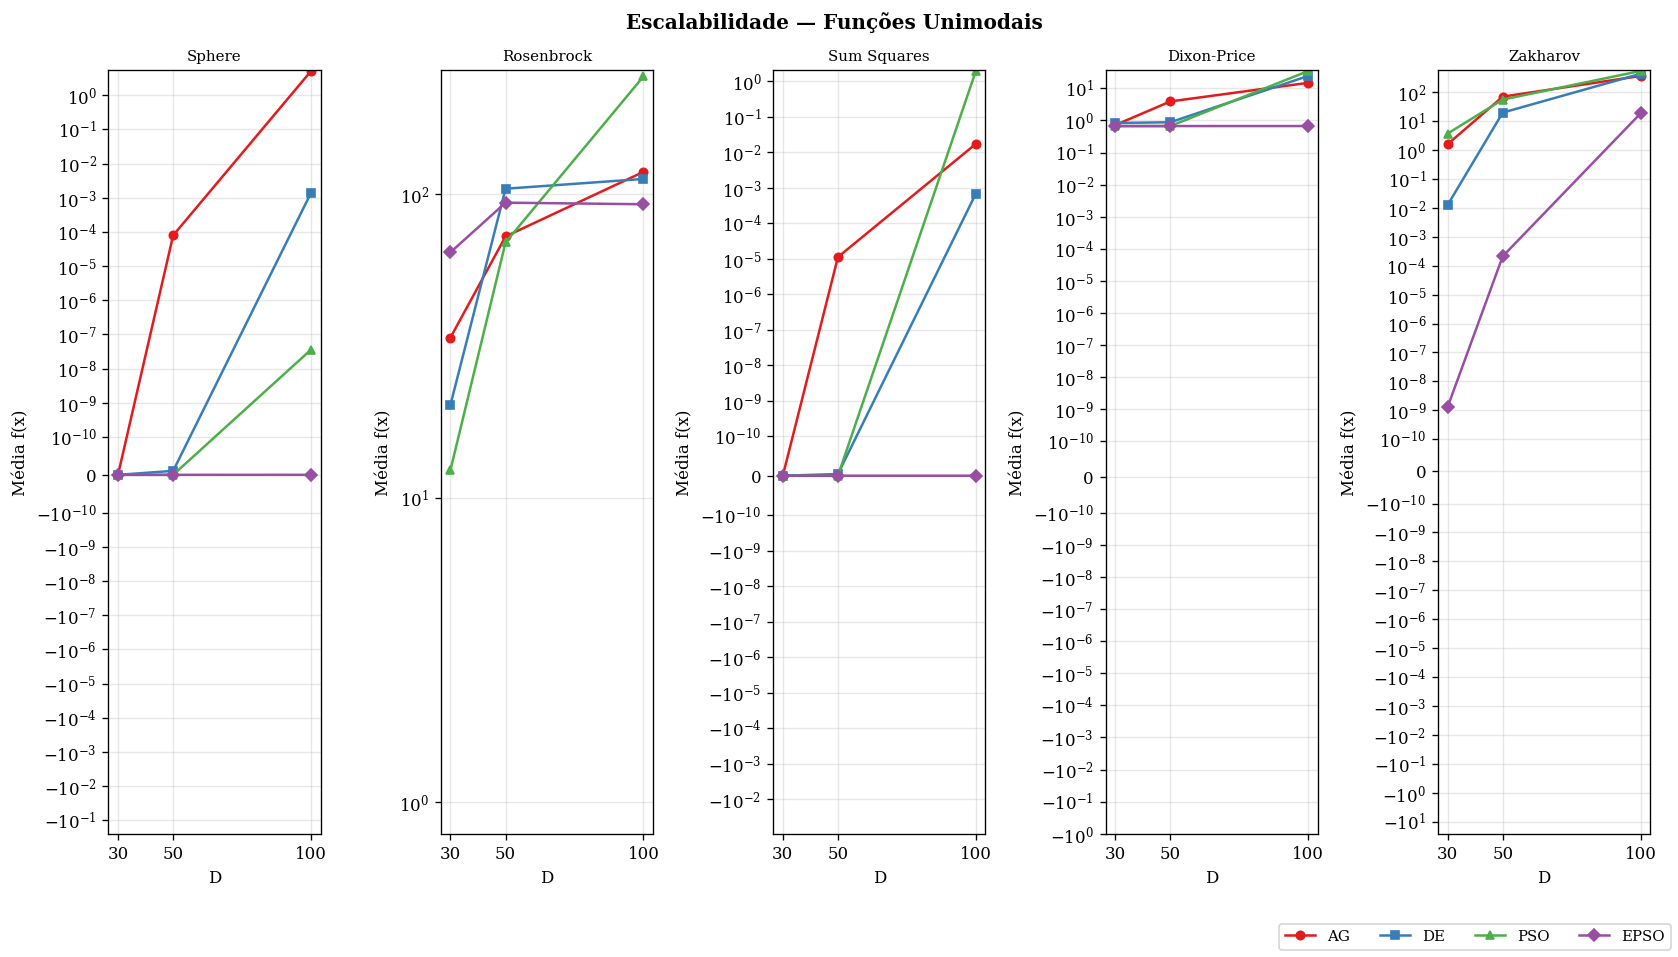

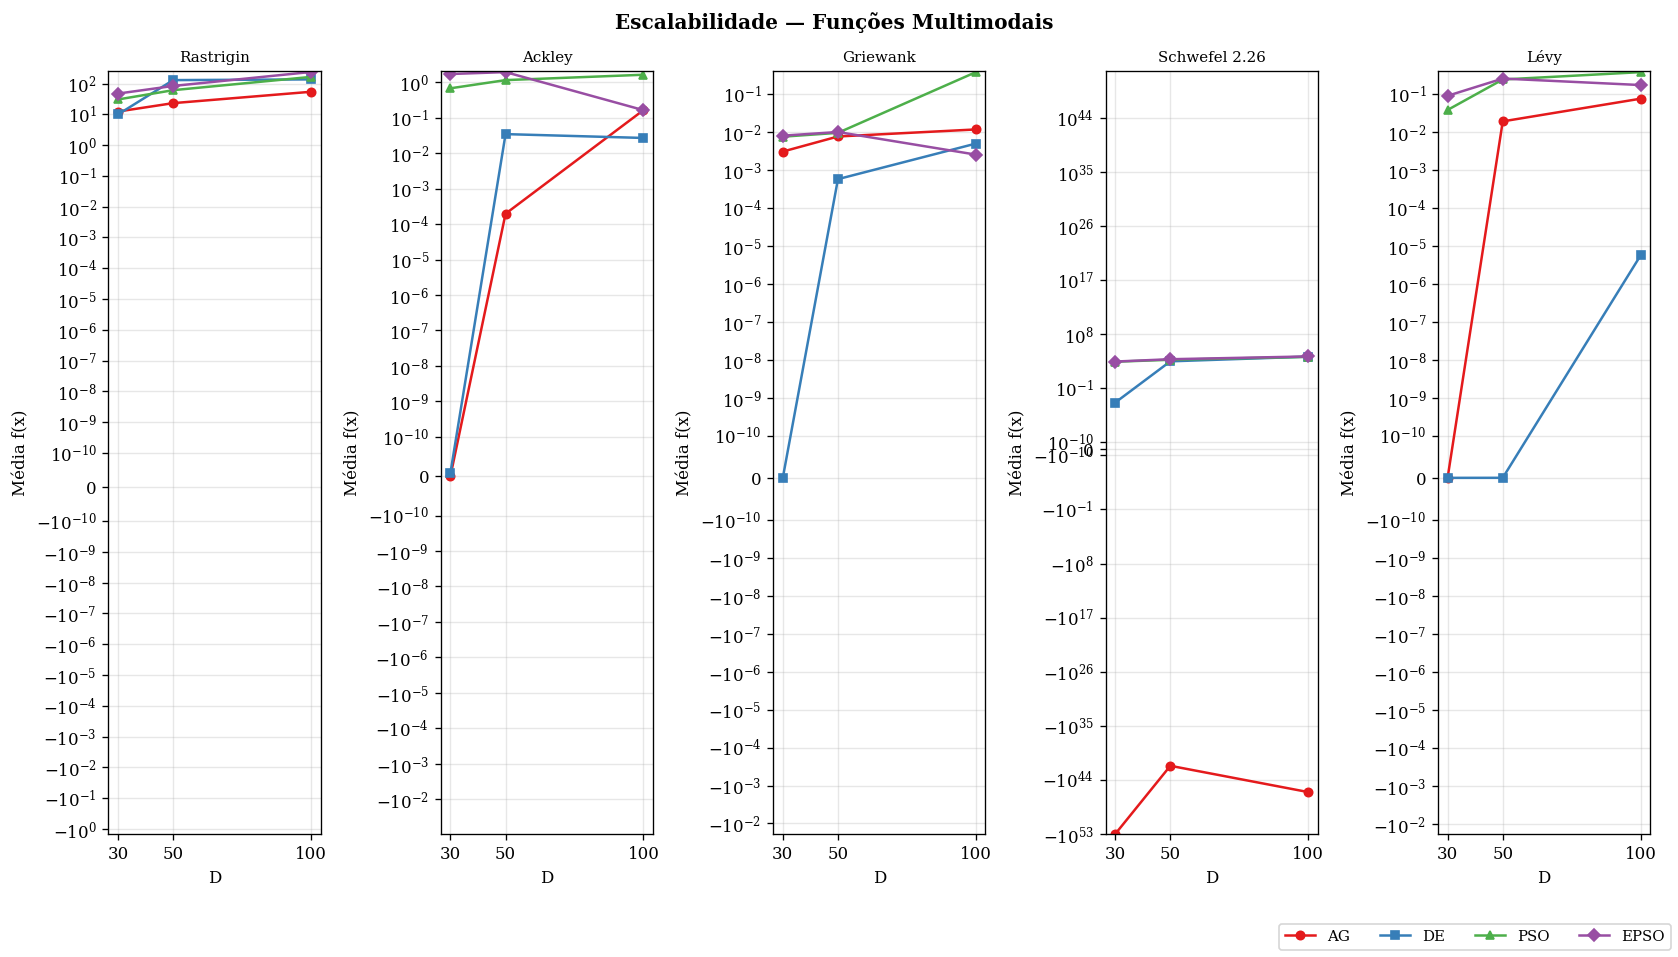

In [31]:
def plot_escalabilidade(funcoes, titulo, figsize=(14, 8)):
    n = len(funcoes)
    ncols = 5
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for idx, fn in enumerate(funcoes):
        ax = axes[idx]
        for alg in ALGORITMOS:
            medias = []
            for dim in DIMS:
                v = res[(res.algoritmo == alg) & (res.funcao == fn) & (res.dim == dim)]['best_f']
                medias.append(v.mean())
            ax.plot(DIMS, medias, label=LABELS[alg],
                    color=COLORS[alg], marker=MARKERS[alg],
                    linewidth=1.5, markersize=5)
        ax.set_title(NOME_FUNCAO[fn], fontsize=9)
        ax.set_xticks(DIMS)
        ax.set_xlabel('D')
        ax.set_yscale('symlog', linthresh=1e-10)
        ax.set_ylabel('Média f(x)')

    # Remove subplots vazios
    for idx in range(n, len(axes)):
        fig.delaxes(axes[idx])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower right', ncol=4, fontsize=9)
    fig.suptitle(titulo, fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(imagens_dir / f'escalabilidade_{titulo[:3].lower()}.png', bbox_inches='tight')
    plt.show()


plot_escalabilidade(UNIMODAIS,   'Escalabilidade — Funções Unimodais')
plot_escalabilidade(MULTIMODAIS, 'Escalabilidade — Funções Multimodais')

In [32]:
# Razão de degradação — mediana(D=100) / mediana(D=30)
# Quanto maior, pior a escalabilidade do algoritmo naquela função.
# Valores próximos de 1 indicam que o algoritmo escala bem.
# Usa mediana para ser robusto a outliers.
#
# Nota: para funções onde mediana(D=30) ≈ 0 (ex: Sphere com PSO),
# a razão é substituída por NaN para evitar divisão por zero.

def razao_degradacao(alpha_zero=1e-12):
    rows = []
    for fn in FUNCOES:
        row = {'Função': NOME_FUNCAO[fn]}
        for alg in ALGORITMOS:
            m30  = res[(res.algoritmo == alg) & (res.funcao == fn) & (res.dim == 30)]['best_f'].median()
            m100 = res[(res.algoritmo == alg) & (res.funcao == fn) & (res.dim == 100)]['best_f'].median()
            if abs(m30) < alpha_zero:
                razao = np.nan  # denominador próximo de zero
            else:
                razao = m100 / m30
            row[LABELS[alg]] = razao
        rows.append(row)

    df = pd.DataFrame(rows).set_index('Função')

    # Highlight: células com maior razão (pior escalabilidade) em vermelho
    def color_razao(val):
        if pd.isna(val):
            return 'background-color: #f0f0f0; color: gray'
        if val > 1000:
            return 'background-color: #ffcccc'
        if val > 100:
            return 'background-color: #ffe5cc'
        if val > 10:
            return 'background-color: #ffffcc'
        return ''

    print('\n' + '═'*70)
    print('  Razão de Degradação — mediana(D=100) / mediana(D=30)')
    print('  NaN = mediana em D=30 próxima de zero (algoritmo convergiu)')
    print('  Vermelho = degradação severa (>1000×)')
    print('═'*70)
    display(df.style.map(color_razao).format('{:.1f}', na_rep='—'))

razao_degradacao()


══════════════════════════════════════════════════════════════════════
  Razão de Degradação — mediana(D=100) / mediana(D=30)
  NaN = mediana em D=30 próxima de zero (algoritmo convergiu)
  Vermelho = degradação severa (>1000×)
══════════════════════════════════════════════════════════════════════


,AG,DE,PSO,EPSO
Função,,,,
Sphere,—,—,—,—
Rosenbrock,17.4,4.8,21.3,1.2
Sum Squares,—,—,—,—
Dixon-Price,21.4,33.5,30.3,1.0
Zakharov,275.9,50812.7,1704944051177.4,37761187129.0
Rastrigin,4.5,13.0,5.4,4.9
Ackley,—,647434464.7,1.9,0.0
Griewank,—,—,21.4,—
Schwefel 2.26,9.4,39958391.7,6.6,7.2


In [33]:
# Consistência / Robustez — Coeficiente de Variação (CV = std / |média|)
# CV baixo → algoritmo previsível (robusto entre execuções)
# CV alto  → algoritmo instável (resultado depende muito da inicialização)
#
# Complemento: teste de Levene para igualdade de variâncias entre algoritmos
# H0: as variâncias são iguais entre todos os algoritmos
# Rejeita H0: algum algoritmo tem dispersão significativamente diferente

from scipy.stats import levene

def coef_variacao(fn, dim):
    rows = []
    for alg in ALGORITMOS:
        vals = res[(res.algoritmo == alg) & (res.funcao == fn) & (res.dim == dim)]['best_f']
        mu   = vals.mean()
        sd   = vals.std()
        cv   = sd / abs(mu) if abs(mu) > 1e-12 else np.nan
        rows.append({'Algoritmo': LABELS[alg], 'Média': mu, 'Std': sd, 'CV': cv})
    return pd.DataFrame(rows).set_index('Algoritmo')


def tabela_robustez(funcoes, titulo):
    print(f'\n{"═"*70}')
    print(f'  Robustez (CV) + Levene — {titulo}')
    print(f'{"═"*70}')

    rows_cv = []
    for fn in funcoes:
        for dim in DIMS:
            cv_df = coef_variacao(fn, dim)

            # Levene
            grupos = [
                res[(res.algoritmo == a) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
                for a in ALGORITMOS
            ]
            _, lev_p = levene(*grupos)

            row = {'Função': NOME_FUNCAO[fn], 'D': dim}
            for alg in ALGORITMOS:
                row[f'CV {LABELS[alg]}'] = cv_df.loc[LABELS[alg], 'CV']
            row['Levene p'] = f'{lev_p:.2e}'
            row['Var. iguais?'] = 'Sim' if lev_p >= 0.05 else 'Não'
            rows_cv.append(row)

    df = pd.DataFrame(rows_cv).set_index(['Função', 'D'])

    def color_cv(val):
        if pd.isna(val):
            return ''
        if val > 1.0:
            return 'background-color: #ffcccc'
        if val > 0.5:
            return 'background-color: #ffffcc'
        return ''

    cv_cols = [f'CV {LABELS[a]}' for a in ALGORITMOS]
    display(df.style.map(color_cv, subset=cv_cols).format(
        {c: '{:.3f}' for c in cv_cols}, na_rep='—'
    ))


tabela_robustez(UNIMODAIS,   'Funções Unimodais')
tabela_robustez(MULTIMODAIS, 'Funções Multimodais')


══════════════════════════════════════════════════════════════════════
  Robustez (CV) + Levene — Funções Unimodais
══════════════════════════════════════════════════════════════════════



══════════════════════════════════════════════════════════════════════
  Robustez (CV) + Levene — Funções Multimodais
══════════════════════════════════════════════════════════════════════


## 7. Velocidade de Convergência

Esta seção avalia **quão cedo** cada algoritmo chega a bons valores, usando o histórico completo de convergência (`his`), não apenas o melhor valor final.

- **AUC da curva de convergência:** integral numérica de `best_f` ao longo dos FEs. Quanto menor a AUC, mais cedo o algoritmo manteve bons valores acumulados.
- **FEs até limiar:** primeira avaliação em que a execução atinge `f(x) < ε`. A tabela mostra a mediana de FEs entre as execuções que atingiram o limiar e a taxa de sucesso.


In [34]:
# Velocidade de convergência
# AUC menor indica que o algoritmo acumulou bons valores mais cedo.
# FEs até limiar mede quantas avaliações são necessárias para atingir f(x) < epsilon.

ALG_COLS = [LABELS[a] for a in ALGORITMOS]


def _trapz(y, x):
    """Compatibilidade entre versões do NumPy: trapezoid é o nome novo de trapz."""
    if hasattr(np, 'trapezoid'):
        return np.trapezoid(y, x)
    return np.trapz(y, x)


def auc_por_execucao():
    rows = []
    cols = ['algoritmo', 'funcao', 'dim', 'exec_id']
    for (alg, fn, dim, eid), grp in his.groupby(cols):
        curva = (
            grp[['n_fes', 'best_f']]
            .dropna()
            .sort_values('n_fes')
            .groupby('n_fes', as_index=False)['best_f']
            .min()
        )
        if len(curva) < 2:
            auc = np.nan
        else:
            auc = _trapz(curva['best_f'].to_numpy(), curva['n_fes'].to_numpy())
        rows.append({
            'algoritmo': alg,
            'funcao': fn,
            'dim': dim,
            'exec_id': eid,
            'AUC': auc,
        })
    return pd.DataFrame(rows)


auc_exec = auc_por_execucao()


def tabela_auc_convergencia(funcoes, titulo):
    rows = []
    for fn in funcoes:
        for dim in DIMS:
            row = {'Função': NOME_FUNCAO[fn], 'D': dim}
            medianas = {}
            for alg in ALGORITMOS:
                vals = auc_exec[
                    (auc_exec.algoritmo == alg) &
                    (auc_exec.funcao == fn) &
                    (auc_exec.dim == dim)
                ]['AUC']
                med = vals.median()
                row[LABELS[alg]] = med
                medianas[alg] = med

            validos = {alg: val for alg, val in medianas.items() if pd.notna(val)}
            row['Melhor'] = LABELS[min(validos, key=validos.get)] if validos else '—'
            rows.append(row)

    df = pd.DataFrame(rows).set_index(['Função', 'D'])

    def highlight_menor(row):
        vals = pd.to_numeric(row, errors='coerce')
        if vals.isna().all():
            return ['' for _ in vals]
        menor = vals.min(skipna=True)
        return [
            'background-color: #d9ead3; font-weight: bold' if pd.notna(v) and np.isclose(v, menor, rtol=1e-12, atol=1e-300) else ''
            for v in vals
        ]

    print()
    print(f'{"═"*80}')
    print(f'  AUC da Curva de Convergência — {titulo}')
    print('  Menor AUC = melhor velocidade acumulada de convergência')
    print(f'{"═"*80}')
    display(
        df.style
          .apply(highlight_menor, subset=ALG_COLS, axis=1)
          .format({c: '{:.3e}' for c in ALG_COLS}, na_rep='—')
    )


def fes_limiar_por_execucao(epsilon=1e-8):
    rows = []
    cols = ['algoritmo', 'funcao', 'dim', 'exec_id']
    for (alg, fn, dim, eid), grp in his.groupby(cols):
        curva = grp[['n_fes', 'best_f']].dropna().sort_values('n_fes')
        atingiu = curva[curva['best_f'] < epsilon]
        fe = atingiu['n_fes'].iloc[0] if len(atingiu) else np.nan
        rows.append({
            'algoritmo': alg,
            'funcao': fn,
            'dim': dim,
            'exec_id': eid,
            'FEs': fe,
        })
    return pd.DataFrame(rows)


def _fmt_fes(valor, taxa):
    if pd.isna(valor):
        return f'— ({taxa:.0f}%)'
    return f'{valor:,.0f} ({taxa:.0f}%)'.replace(',', '.')


def tabela_fes_limiar(funcoes, titulo, epsilon=1e-8):
    fes_exec = fes_limiar_por_execucao(epsilon)
    rows = []
    for fn in funcoes:
        for dim in DIMS:
            row = {'Função': NOME_FUNCAO[fn], 'D': dim}
            medianas = {}
            for alg in ALGORITMOS:
                vals = fes_exec[
                    (fes_exec.algoritmo == alg) &
                    (fes_exec.funcao == fn) &
                    (fes_exec.dim == dim)
                ]['FEs']
                taxa = vals.notna().mean() * 100
                med = vals.median(skipna=True)
                row[LABELS[alg]] = _fmt_fes(med, taxa)
                medianas[alg] = med

            validos = {alg: val for alg, val in medianas.items() if pd.notna(val)}
            row['Mais rápido'] = LABELS[min(validos, key=validos.get)] if validos else '—'
            rows.append(row)

    df = pd.DataFrame(rows).set_index(['Função', 'D'])

    print()
    print(f'{"═"*80}')
    print(f'  FEs para atingir f(x) < {epsilon:.0e} — {titulo}')
    print('  Formato: mediana de FEs entre execuções bem-sucedidas (taxa de sucesso)')
    print(f'{"═"*80}')
    display(df)


def ranking_velocidade_auc():
    rows = []
    for dim in DIMS:
        vitorias = {alg: 0 for alg in ALGORITMOS}
        for fn in FUNCOES:
            vals = {
                alg: auc_exec[
                    (auc_exec.algoritmo == alg) &
                    (auc_exec.funcao == fn) &
                    (auc_exec.dim == dim)
                ]['AUC'].median()
                for alg in ALGORITMOS
            }
            vals = {alg: val for alg, val in vals.items() if pd.notna(val)}
            if vals:
                vitorias[min(vals, key=vals.get)] += 1
        rows.append({'D': dim, **{LABELS[a]: vitorias[a] for a in ALGORITMOS}})

    print()
    print('Ranking de velocidade por AUC: número de funções em que cada algoritmo teve a menor AUC mediana')
    display(pd.DataFrame(rows).set_index('D'))


tabela_auc_convergencia(UNIMODAIS,   'Funções Unimodais')
tabela_auc_convergencia(MULTIMODAIS, 'Funções Multimodais')
ranking_velocidade_auc()

tabela_fes_limiar(UNIMODAIS,   'Funções Unimodais',   epsilon=1e-8)
tabela_fes_limiar(MULTIMODAIS, 'Funções Multimodais', epsilon=1e-8)



════════════════════════════════════════════════════════════════════════════════
  AUC da Curva de Convergência — Funções Unimodais
  Menor AUC = melhor velocidade acumulada de convergência
════════════════════════════════════════════════════════════════════════════════



════════════════════════════════════════════════════════════════════════════════
  AUC da Curva de Convergência — Funções Multimodais
  Menor AUC = melhor velocidade acumulada de convergência
════════════════════════════════════════════════════════════════════════════════



Ranking de velocidade por AUC: número de funções em que cada algoritmo teve a menor AUC mediana


,AG,DE,PSO,EPSO
D,,,,
30,4,0,6,0
50,3,0,7,0
100,2,0,7,1



════════════════════════════════════════════════════════════════════════════════
  FEs para atingir f(x) < 1e-08 — Funções Unimodais
  Formato: mediana de FEs entre execuções bem-sucedidas (taxa de sucesso)
════════════════════════════════════════════════════════════════════════════════


AG             DE            PSO           EPSO  \
Função      D                                                                 
Sphere      30   27.500 (100%)  51.400 (100%)  12.000 (100%)  32.700 (100%)   
            50          — (0%)  79.100 (100%)  26.400 (100%)  46.100 (100%)   
            100         — (0%)         — (0%)   90.300 (96%)  69.700 (100%)   
Rosenbrock  30          — (0%)         — (0%)         — (0%)         — (0%)   
            50          — (0%)         — (0%)         — (0%)         — (0%)   
            100         — (0%)         — (0%)         — (0%)         — (0%)   
Sum Squares 30   29.200 (100%)  45.300 (100%)  11.500 (100%)  29.700 (100%)   
            50          — (0%)  76.900 (100%)  25.500 (100%)  44.500 (100%)   
            100         — (0%)         — (0%)   96.700 (39%)  67.700 (100%)   
Dixon-Price 30          — (0%)         — (0%)         — (0%)         — (0%)   
            50          — (0%)         — (0%)         — (0%)         — (0%)   
            100         — (0%)         — (0%)         — (0%)         — (0%)   
Zakharov    30          — (0%)         — (0%)   83.100 (69%)   88.700 (96%)   
            50          — (0%)         — (0%)         — (0%)         — (0%)   
            100         — (0%)         — (0%)         — (0%)         — (0%)   

                Mais rápido  
Função      D                
Sphere      30          PSO  
            50          PSO  
            100        EPSO  
Rosenbrock  30            —  
            50            —  
            100           —  
Sum Squares 30          PSO  
            50          PSO  
            100        EPSO  
Dixon-Price 30            —  
            50            —  
            100           —  
Zakharov    30          PSO  
            50            —  
            100           —


════════════════════════════════════════════════════════════════════════════════
  FEs para atingir f(x) < 1e-08 — Funções Multimodais
  Formato: mediana de FEs entre execuções bem-sucedidas (taxa de sucesso)
════════════════════════════════════════════════════════════════════════════════


AG             DE           PSO          EPSO  \
Função        D                                                               
Rastrigin     30          — (0%)         — (0%)        — (0%)        — (0%)   
              50          — (0%)         — (0%)        — (0%)        — (0%)   
              100         — (0%)         — (0%)        — (0%)        — (0%)   
Ackley        30   52.400 (100%)  75.900 (100%)  26.900 (49%)  69.000 (24%)   
              50          — (0%)         — (0%)  91.500 (33%)  87.400 (12%)   
              100         — (0%)         — (0%)        — (0%)   99.500 (8%)   
Griewank      30    25.400 (73%)  63.500 (100%)  21.800 (49%)  49.300 (57%)   
              50    71.600 (69%)   79.850 (94%)  41.400 (47%)  57.800 (47%)   
              100         — (0%)         — (0%)  89.600 (14%)  69.700 (80%)   
Schwefel 2.26 30    1.800 (100%)         — (0%)        — (0%)        — (0%)   
              50    2.200 (100%)         — (0%)        — (0%)        — (0%)   
              100   2.600 (100%)         — (0%)        — (0%)        — (0%)   
Lévy          30   22.400 (100%)  38.800 (100%)  15.700 (96%)  37.000 (90%)   
              50          — (0%)  65.800 (100%)  25.700 (80%)  64.900 (82%)   
              100         — (0%)         — (0%)  77.350 (59%)        — (0%)   

                  Mais rápido  
Função        D                
Rastrigin     30            —  
              50            —  
              100           —  
Ackley        30          PSO  
              50         EPSO  
              100        EPSO  
Griewank      30          PSO  
              50          PSO  
              100        EPSO  
Schwefel 2.26 30           AG  
              50           AG  
              100          AG  
Lévy          30          PSO  
              50          PSO  
              100         PSO

## 8. Ranking Consolidado

Contagem de vitórias no Teste T por algoritmo, separado por grupo de função e dimensão.

In [35]:
import pandas as pd
import numpy as np
from itertools import combinations
# Importando o Teste T para amostras independentes ao invés de Mann-Whitney
from scipy.stats import ttest_ind 

def ranking_consolidado_teste_t(alpha=0.05):
    """
    Contagem de vitórias usando o Teste T de Welch para amostras independentes.
    Para cada par de algoritmos por função/dimensão:
      - Rejeita H0 (p < alpha): vencedor é o de menor média (estatisticamente menor)
      - Não rejeita H0 (p >= alpha): empate (nenhum ganha ponto)
    """
    pares = list(combinations(ALGORITMOS, 2))
    vitorias = {alg: 0 for alg in ALGORITMOS}
    rows = []

    for fn in FUNCOES:
        for dim in DIMS:
            vit_dim = {alg: 0 for alg in ALGORITMOS}
            
            for a1, a2 in pares:
                # Extraindo os vetores de resultados (melhores valores de fitness encontrados)
                v1 = res[(res.algoritmo == a1) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
                v2 = res[(res.algoritmo == a2) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
                
                # Prevenção de erros: O Teste T falha se o vetor estiver vazio ou tiver 1 elemento
                if len(v1) < 2 or len(v2) < 2:
                    continue
                
                # Executa o Teste T de Welch (equal_var=False assume que as variâncias não são iguais)
                # O teste retorna a estatística t e o valor-p (probabilidade)
                stat, pval = ttest_ind(v1, v2, equal_var=False)
                
                # Se p-valor for menor que alpha, rejeitamos a hipótese de médias iguais
                if pval < alpha:
                    # Avalia a MÉDIA ao invés da mediana para declarar o vencedor
                    if np.mean(v1) < np.mean(v2):
                        vit_dim[a1] += 1
                        vitorias[a1] += 1
                    else:
                        vit_dim[a2] += 1
                        vitorias[a2] += 1
                        
            # Armazena os resultados para a tabela final
            rows.append({
                'Função': NOME_FUNCAO[fn],
                'D': dim,
                **{LABELS[a]: vit_dim[a] for a in ALGORITMOS}
            })

    # Construção e exibição das tabelas usando Pandas
    df = pd.DataFrame(rows).set_index(['Função', 'D'])
    print('Vitórias por função e dimensão (Teste T de Welch, α=5%):')
    display(df)

    print('\nRanking geral (total de vitórias):')
    ranking = pd.Series(vitorias).rename(index=LABELS).sort_values(ascending=False)
    display(ranking.to_frame('Vitórias'))

# Executa a função
ranking_consolidado_teste_t()

Vitórias por função e dimensão (Teste T de Welch, α=5%):


AG  DE  PSO  EPSO
Função        D                     
Sphere        30    0   0    1     1
              50    0   1    3     2
              100   0   0    1     1
Rosenbrock    30    1   2    3     0
              50    2   0    2     0
              100   1   1    0     3
Sum Squares   30    1   0    1     1
              50    0   1    3     2
              100   0   1    0     2
Dixon-Price   30    0   0    1     1
              50    0   1    1     1
              100   2   0    0     3
Zakharov      30    0   2    0     3
              50    0   2    0     3
              100   2   1    0     3
Rastrigin     30    2   3    1     0
              50    3   0    2     1
              100   3   2    1     0
Ackley        30    3   2    1     0
              50    2   2    1     0
              100   1   2    0     1
Griewank      30    2   3    0     0
              50    0   3    0     0
              100   1   1    0     1
Schwefel 2.26 30    0   2    0     0
              50    0   2    1     0
              100   0   0    1     0
Lévy          30    2   1    0     0
              50    2   2    0     0
              100   1   3    0     0


Ranking geral (total de vitórias):


,Vitórias
DE,40
AG,31
EPSO,29
PSO,24


In [36]:
def ranking_consolidado(alpha=0.05):
    """
    Contagem de vitórias usando Wilcoxon Rank-Sum (Mann-Whitney U).
    Para cada par de algoritmos por função/dimensão:
      - Rejeita H0 (p < alpha): vencedor é o de menor mediana
      - Não rejeita H0: empate
    """
    from scipy.stats import mannwhitneyu
    pares    = list(combinations(ALGORITMOS, 2))
    vitorias = {alg: 0 for alg in ALGORITMOS}
    rows     = []

    for fn in FUNCOES:
        for dim in DIMS:
            vit_dim = {alg: 0 for alg in ALGORITMOS}
            for a1, a2 in pares:
                v1 = res[(res.algoritmo == a1) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
                v2 = res[(res.algoritmo == a2) & (res.funcao == fn) & (res.dim == dim)]['best_f'].values
                _, pval = mannwhitneyu(v1, v2, alternative='two-sided')
                if pval < alpha:
                    if np.median(v1) < np.median(v2):
                        vit_dim[a1] += 1
                        vitorias[a1] += 1
                    else:
                        vit_dim[a2] += 1
                        vitorias[a2] += 1
            rows.append({
                'Função': NOME_FUNCAO[fn],
                'D': dim,
                **{LABELS[a]: vit_dim[a] for a in ALGORITMOS}
            })

    df = pd.DataFrame(rows).set_index(['Função', 'D'])
    print('Vitórias por função e dimensão (Wilcoxon, α=5%):')
    display(df)

    print('\nRanking geral (total de vitórias):')
    ranking = pd.Series(vitorias).rename(index=LABELS).sort_values(ascending=False)
    display(ranking.to_frame('Vitórias'))

ranking_consolidado()


Vitórias por função e dimensão (Wilcoxon, α=5%):


AG  DE  PSO  EPSO
Função        D                     
Sphere        30    1   0    3     2
              50    0   1    3     2
              100   1   0    2     3
Rosenbrock    30    1   1    2     0
              50    2   0    2     0
              100   1   1    0     2
Sum Squares   30    1   0    3     2
              50    0   1    3     2
              100   0   1    2     3
Dixon-Price   30    0   0    2     2
              50    0   1    3     1
              100   2   0    0     3
Zakharov      30    0   1    2     2
              50    0   2    1     3
              100   2   1    0     3
Rastrigin     30    2   3    1     0
              50    3   0    2     1
              100   3   2    1     0
Ackley        30    3   1    1     0
              50    2   3    1     0
              100   1   2    0     3
Griewank      30    2   2    0     0
              50    0   1    0     0
              100   1   1    0     3
Schwefel 2.26 30    3   2    0     0
              50    3   2    1     0
              100   3   1    1     0
Lévy          30    2   0    3     0
              50    0   2    3     1
              100   0   2    3     1


Ranking geral (total de vitórias):


,Vitórias
PSO,45
AG,39
EPSO,39
DE,34


## 9. Painel de Convergência Selecionado (para o artigo)

Seleciona os casos mais representativos para compor uma figura compacta no artigo LNCS:  
- 1 unimodal simples (Sphere) — baseline  
- 1 unimodal difícil (Rosenbrock) — vale estreito  
- 1 multimodal densa (Rastrigin) — grade de ótimos locais  
- 1 multimodal deceptiva (Schwefel) — ótimo periférico  

Para cada: subplots de 30D e 100D lado a lado.

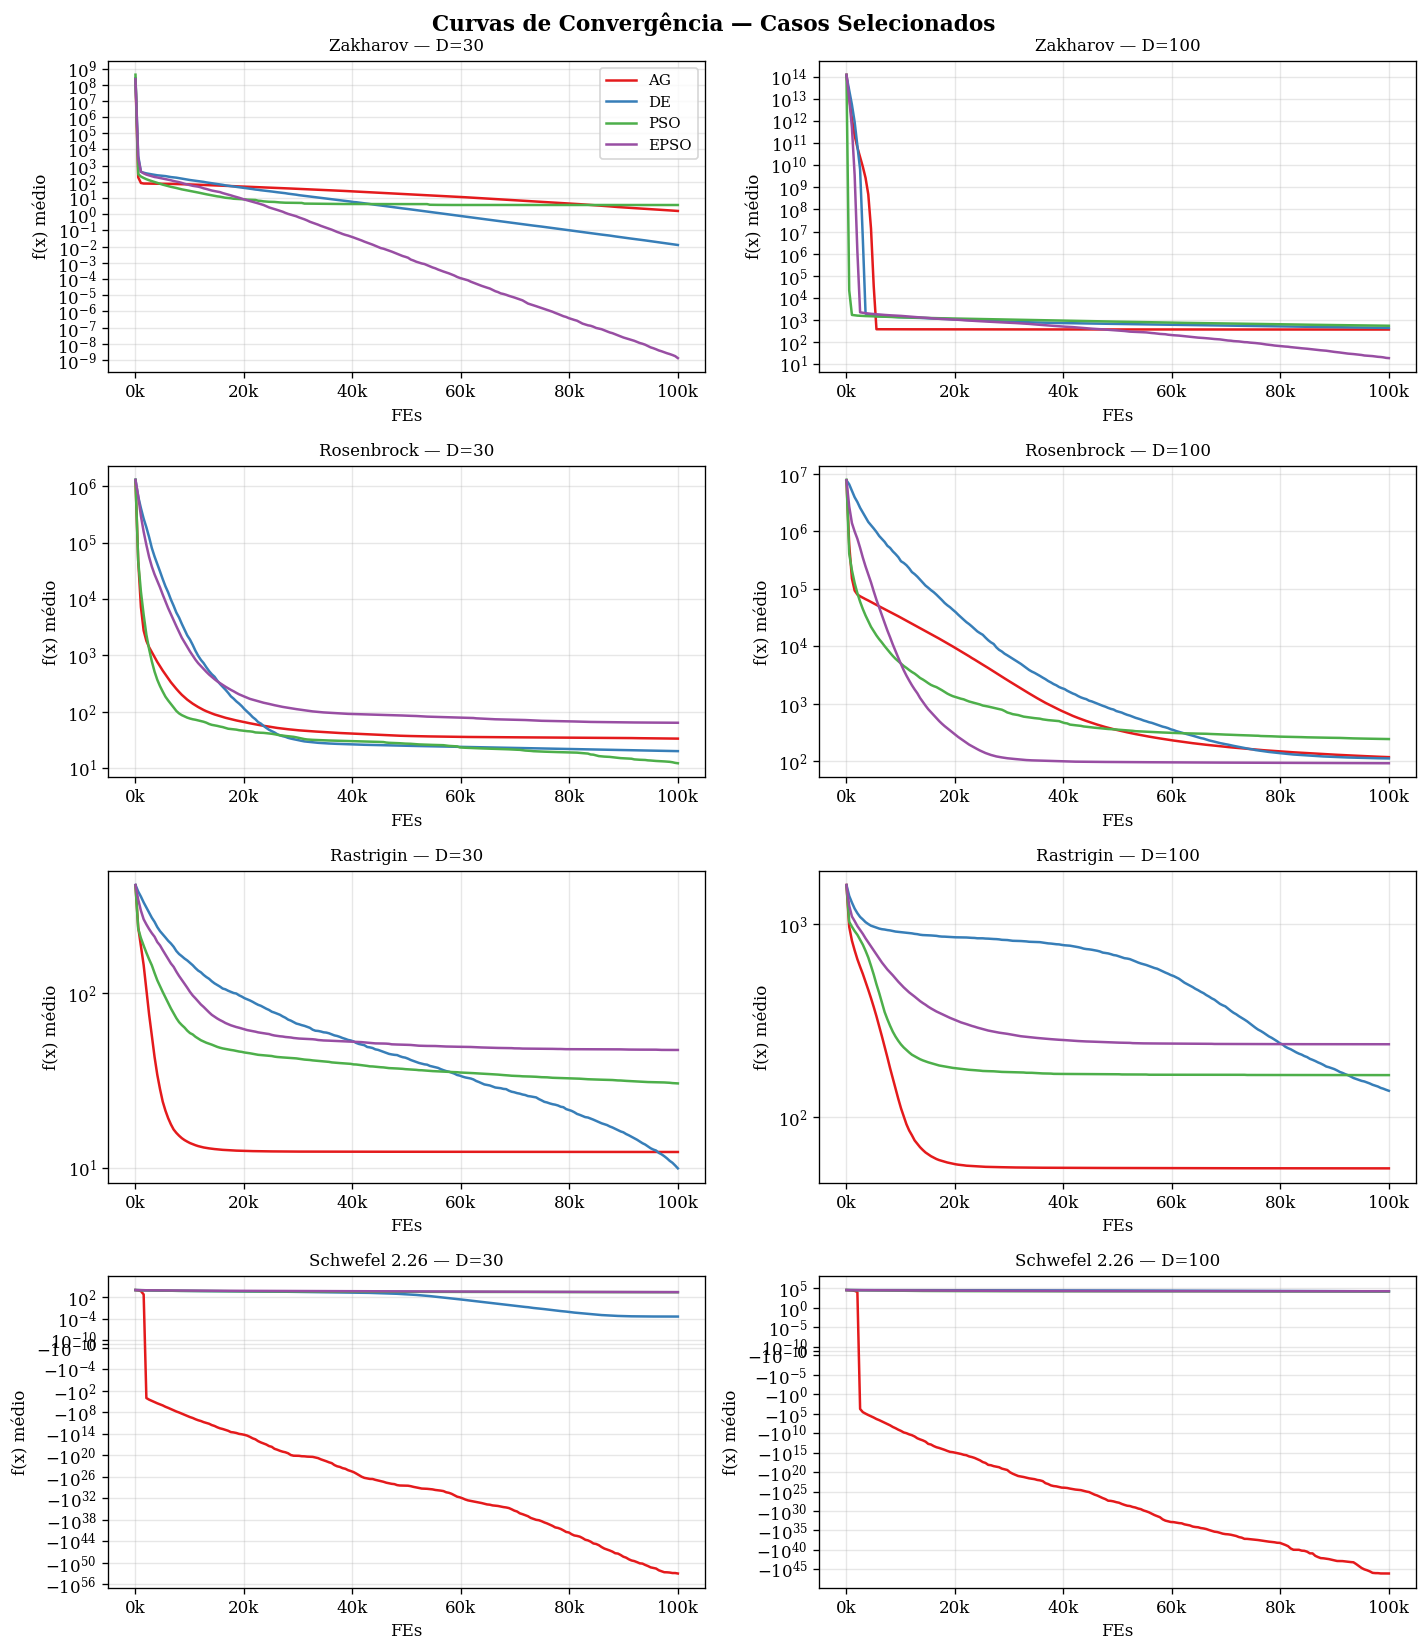

Figura salva: c:\Users\Pichau\Documents\REPOSITÓRIOS\obsidian_notebook\Otimização com Metaheurísticas\Trabalho Final\imagens\convergencia_artigo.png


In [37]:
SELECAO_ARTIGO = [
    ('zakharov',     [30, 100]),
    ('rosenbrock', [30, 100]),
    ('rastrigin',  [30, 100]),
    ('schwefel',   [30, 100]),
]

fig, axes = plt.subplots(len(SELECAO_ARTIGO), 2,
                         figsize=(12, 3.5 * len(SELECAO_ARTIGO)))

for row_idx, (fn, dims) in enumerate(SELECAO_ARTIGO):
    for col_idx, dim in enumerate(dims):
        ax = axes[row_idx, col_idx]
        for alg in ALGORITMOS:
            grid, mu, sd = convergencia_media(his, alg, fn, dim)
            ax.plot(grid, mu, label=LABELS[alg],
                    color=COLORS[alg], linewidth=1.5)
            
        ax.set_yscale('symlog', linthresh=1e-10)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
        ax.set_title(f'{NOME_FUNCAO[fn]} — D={dim}', fontsize=10)
        ax.set_xlabel('FEs')
        ax.set_ylabel('f(x) médio')
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='upper right')

plt.suptitle('Curvas de Convergência — Casos Selecionados', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(imagens_dir / 'convergencia_artigo.png', bbox_inches='tight')
plt.show()
print(f'Figura salva: {imagens_dir / "convergencia_artigo.png"}')